# Options Backtest — Full Data & Performance Analysis
### Quant-Level Review | NVDA/AAPL/TSLA/… | Feb 13 – Mar 27 2026
---
**Coverage:**  
1. Raw IV universe — contract distribution, IV quality, bid-ask spreads  
2. Contract filtering waterfall  
3. Underlying & macro (realized vol, VIX, rf)  
4. Heston calibration quality — convergence, IVRMSE, parameter stability, Feller  
5. IV surface — ATM IV, skew, butterfly  
6. Signal analysis — S1 z-scores, S2 GEX regimes, S4 (never fired)  
7. Trade analytics — exit reasons, hold times, gross→net waterfall  
8. Portfolio performance — equity curve, attribution, rolling Sharpe, IS/OOS  
9. Risk flags & noteworthy observations

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import seaborn as sns
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT    = Path('.')
DATA    = ROOT / 'data'
RESULTS = ROOT / 'results'

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.titleweight': 'bold',
})
PALETTE = sns.color_palette('tab10', 10)
TICKER_CLR = {t: PALETTE[i] for i, t in enumerate(
    ['AAPL','AMZN','DIS','GOOGL','JPM','META','MSFT','NVDA','TSLA','V'])}

IS_END  = pd.Timestamp('2026-02-27')
INSAMPLE_COLOR = '#e8f4e8'
OOS_COLOR      = '#fff3cd'

print('Imports OK')

Imports OK


In [2]:
iv_df       = pd.read_parquet(DATA / 'iv_data.parquet')
stock_df    = pd.read_parquet(DATA / 'stock_bars.parquet')
ext_df      = pd.read_parquet(DATA / 'external_data.parquet')
heston_df   = pd.read_parquet(DATA / 'heston_params.parquet')
surf_df     = pd.read_parquet(DATA / 'iv_surfaces.parquet')
greeks_df   = pd.read_parquet(DATA / 'intraday_greeks.parquet')
sig1_df     = pd.read_parquet(DATA / 'signals_s1.parquet')
sig2_df     = pd.read_parquet(DATA / 'signals_s2.parquet')
sig4_df     = pd.read_parquet(DATA / 'signals_s4.parquet')

tl_df       = pd.read_parquet(RESULTS / 'trade_log_net.parquet')
dpnl_df     = pd.read_parquet(RESULTS / 'daily_pnl_net.parquet')
dpnl_comb   = pd.read_parquet(RESULTS / 'daily_pnl_combined.parquet')
rsh_df      = pd.read_parquet(RESULTS / 'rolling_sharpe.parquet')

# ── Normalise timestamps ───────────────────────────────────────────────────
iv_df['report_date']     = pd.to_datetime(iv_df['report_time']).dt.date
stock_df['timestamp']    = pd.to_datetime(stock_df['timestamp'])
ext_df['date']           = pd.to_datetime(ext_df['date'])
heston_df['date']        = pd.to_datetime(heston_df['date'])
surf_df['timestamp']     = pd.to_datetime(surf_df['timestamp'])
tl_df['entry_time']      = pd.to_datetime(tl_df['entry_time'])
tl_df['exit_time']       = pd.to_datetime(tl_df['exit_time'])
tl_df['hold_min']        = (tl_df['exit_time'] - tl_df['entry_time']).dt.total_seconds() / 60
tl_df['is_oos']          = tl_df['entry_time'].dt.date > IS_END.date()
dpnl_df['date']          = pd.to_datetime(dpnl_df['date'])
dpnl_comb['date']        = pd.to_datetime(dpnl_comb['date'])
rsh_df['date']           = pd.to_datetime(rsh_df['date'])

TICKERS = sorted(iv_df['ticker'].unique())

# ── Summary table ──────────────────────────────────────────────────────────
rows = [
    ('iv_data.parquet',       f'{len(iv_df):,}',    'Option chain snapshots (cleaned, IV computed)'),
    ('stock_bars.parquet',    f'{len(stock_df):,}',  '15-min OHLCV bars + realized vol'),
    ('external_data.parquet', f'{len(ext_df):,}',   'VIX, rf-rate, div yields — daily'),
    ('heston_params.parquet', f'{len(heston_df):,}', 'Heston calibration per ticker×day'),
    ('iv_surfaces.parquet',   f'{len(surf_df):,}',  'ATM IV, 25d skew/butterfly per slice'),
    ('intraday_greeks.parquet',f'{len(greeks_df):,}','Heston + BS greeks per contract×bar'),
    ('signals_s1.parquet',    f'{len(sig1_df):,}',  'S1 IV z-score signals'),
    ('signals_s2.parquet',    f'{len(sig2_df):,}',  'S2 GEX regime signals'),
    ('signals_s4.parquet',    f'{len(sig4_df):,}',  'S4 PCR opening signals'),
    ('trade_log_net.parquet', f'{len(tl_df):,}',    'Net trade log (all executed trades)'),
    ('daily_pnl_net.parquet', f'{len(dpnl_df):,}',  'Daily P&L decomposed by strategy'),
]
tbl = pd.DataFrame(rows, columns=['File','Rows','Description'])
print(tbl.to_string(index=False))
print(f'\nBacktest window : 2026-02-13 → 2026-03-27  ({dpnl_df["date"].nunique()} trading days)')
print(f'Tickers         : {TICKERS}')
print(f'Total trades    : {len(tl_df)} (S1 short straddle only)')

                   File      Rows                                   Description
        iv_data.parquet 2,239,024 Option chain snapshots (cleaned, IV computed)
     stock_bars.parquet     7,800              15-min OHLCV bars + realized vol
  external_data.parquet        50              VIX, rf-rate, div yields — daily
  heston_params.parquet       280             Heston calibration per ticker×day
    iv_surfaces.parquet    51,923          ATM IV, 25d skew/butterfly per slice
intraday_greeks.parquet   530,361           Heston + BS greeks per contract×bar
     signals_s1.parquet     1,552                         S1 IV z-score signals
     signals_s2.parquet     7,976                         S2 GEX regime signals
     signals_s4.parquet       157                        S4 PCR opening signals
  trade_log_net.parquet        71           Net trade log (all executed trades)
  daily_pnl_net.parquet        28              Daily P&L decomposed by strategy

Backtest window : 2026-02-13 → 2026-03-

## 1 · Raw IV Universe — Contract Distribution & IV Quality

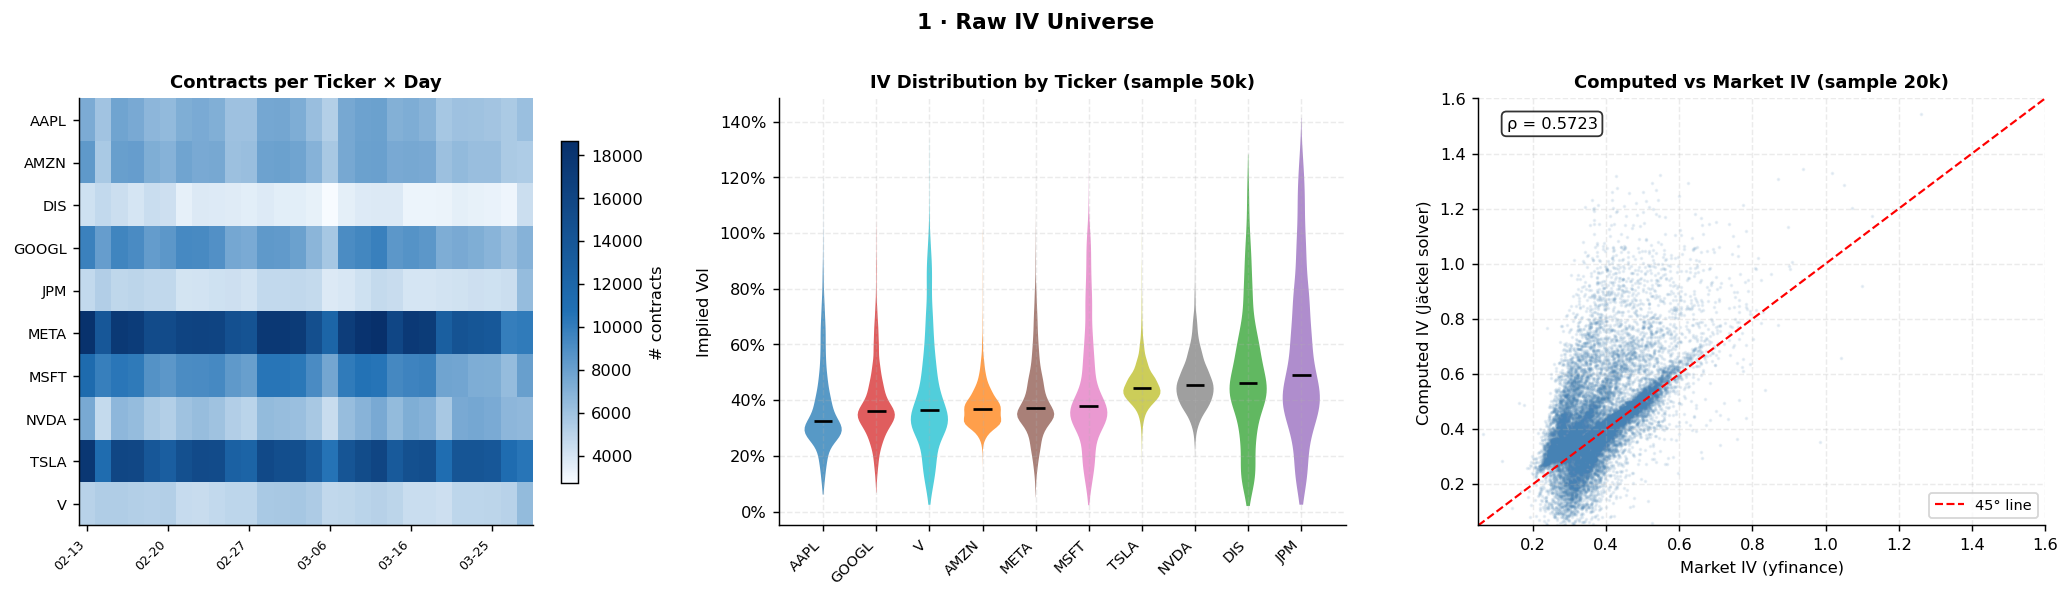

IV range (computed):  [0.0122, 1.8939]  mean=0.4277  median=0.4026
iv < 0.01: 0  |  iv > 2.0: 0
Calls: 1,327,970  |  Puts: 911,054
Bid-ask spread: mean=0.557  median=0.200


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ── 1a: Contract counts per (ticker, date) heatmap ─────────────────────────
iv_df['report_date_ts'] = pd.to_datetime(iv_df['report_date'])
daily_counts = (iv_df.groupby(['ticker','report_date_ts'])
                .size().reset_index(name='n'))
pivot = daily_counts.pivot(index='ticker', columns='report_date_ts', values='n').fillna(0)
pivot.columns = pivot.columns.strftime('%m-%d')
ax = axes[0]
cmap = LinearSegmentedColormap.from_list('', ['#f7fbff','#2171b5','#08306b'])
im = ax.imshow(pivot.values, aspect='auto', cmap=cmap)
ax.set_xticks(np.arange(0, pivot.shape[1], 5))
ax.set_xticklabels(pivot.columns[::5], rotation=45, ha='right', fontsize=7)
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_title('Contracts per Ticker × Day')
plt.colorbar(im, ax=ax, shrink=0.8, label='# contracts')
ax.grid(False)

# ── 1b: IV distribution violin per ticker ──────────────────────────────────
ax = axes[1]
iv_sample = iv_df[['ticker','iv']].sample(50000, random_state=42)
order = (iv_sample.groupby('ticker')['iv'].median().sort_values().index.tolist())
vp = ax.violinplot(
    [iv_sample[iv_sample['ticker']==t]['iv'].values for t in order],
    positions=range(len(order)), widths=0.7,
    showmedians=True, showextrema=False)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(TICKER_CLR[order[i]])
    body.set_alpha(0.75)
vp['cmedians'].set_color('k')
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Implied Vol')
ax.set_title('IV Distribution by Ticker (sample 50k)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))

# ── 1c: Computed IV vs market_iv scatter ──────────────────────────────────
ax = axes[2]
smp = iv_df[iv_df['market_iv'] > 0.01][['iv','market_iv']].sample(20000, random_state=7)
ax.scatter(smp['market_iv'], smp['iv'], s=1, alpha=0.1, color='steelblue', rasterized=True)
lo, hi = 0.05, 1.6
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.2, label='45° line')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel('Market IV (yfinance)'); ax.set_ylabel('Computed IV (Jäckel solver)')
ax.set_title('Computed vs Market IV (sample 20k)')
corr = smp.corr().loc['market_iv','iv']
ax.text(0.05, 0.93, f'ρ = {corr:.4f}', transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
ax.legend(fontsize=8)

plt.suptitle('1 · Raw IV Universe', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Print stats ────────────────────────────────────────────────────────────
print('IV range (computed):  [{:.4f}, {:.4f}]  mean={:.4f}  median={:.4f}'.format(
    iv_df['iv'].min(), iv_df['iv'].max(), iv_df['iv'].mean(), iv_df['iv'].median()))
print(f'iv < 0.01: {(iv_df["iv"]<0.01).sum()}  |  iv > 2.0: {(iv_df["iv"]>2.0).sum()}')
print(f'Calls: {(iv_df["type"]=="c").sum():,}  |  Puts: {(iv_df["type"]=="p").sum():,}')
print(f'Bid-ask spread: mean={( iv_df["ask"]-iv_df["bid"]).mean():.3f}  median={(iv_df["ask"]-iv_df["bid"]).median():.3f}')

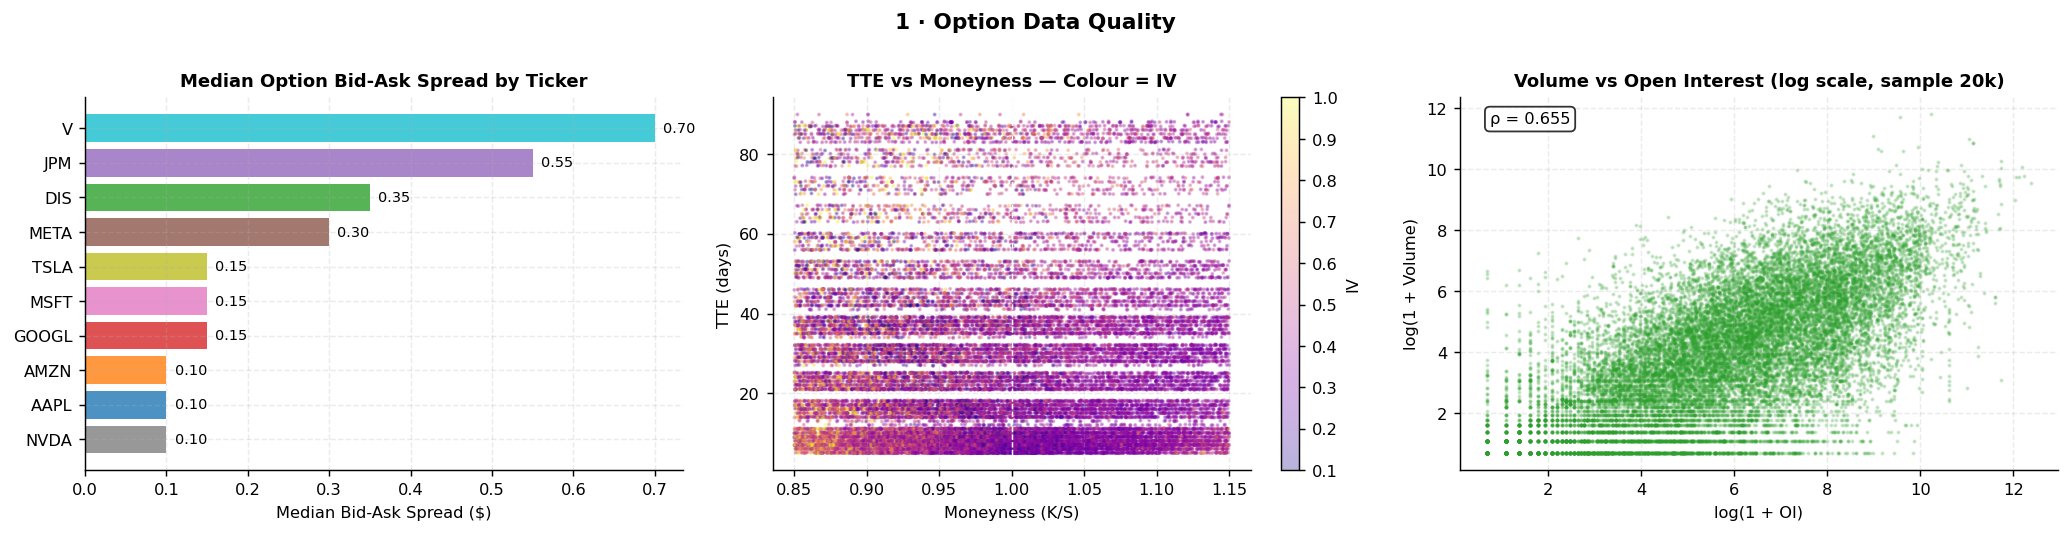

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Bid-ask spread histogram by ticker ────────────────────────────────────
ax = axes[0]
iv_df['spread'] = iv_df['ask'] - iv_df['bid']
spread_ticks = iv_df.groupby('ticker')['spread'].median().sort_values()
colors_ordered = [TICKER_CLR[t] for t in spread_ticks.index]
ax.barh(spread_ticks.index, spread_ticks.values, color=colors_ordered, alpha=0.8)
ax.set_xlabel('Median Bid-Ask Spread ($)')
ax.set_title('Median Option Bid-Ask Spread by Ticker')
for i, v in enumerate(spread_ticks.values):
    ax.text(v+0.01, i, f'{v:.2f}', va='center', fontsize=8)

# ── TTE vs moneyness scatter (coloured by IV) ──────────────────────────────
ax = axes[1]
smp2 = iv_df.sample(30000, random_state=13)
smp2['moneyness'] = smp2['strike'] / smp2['spot']
sc = ax.scatter(smp2['moneyness'], smp2['tte']*365, c=smp2['iv'],
                s=1.5, alpha=0.3, cmap='plasma', vmin=0.1, vmax=1.0, rasterized=True)
plt.colorbar(sc, ax=ax, label='IV')
ax.set_xlabel('Moneyness (K/S)'); ax.set_ylabel('TTE (days)')
ax.set_title('TTE vs Moneyness — Colour = IV')
ax.axvline(1.0, color='white', lw=0.8, ls='--')

# ── Volume vs OI scatter (log-log) ────────────────────────────────────────
ax = axes[2]
smp3 = iv_df[(iv_df['volume']>0) & (iv_df['oi']>0)].sample(20000, random_state=99)
ax.scatter(np.log1p(smp3['oi']), np.log1p(smp3['volume']),
           s=1.5, alpha=0.2, color='#2ca02c', rasterized=True)
ax.set_xlabel('log(1 + OI)'); ax.set_ylabel('log(1 + Volume)')
ax.set_title('Volume vs Open Interest (log scale, sample 20k)')
corr_voi = np.corrcoef(np.log1p(smp3['oi']), np.log1p(smp3['volume']))[0,1]
ax.text(0.05, 0.93, f'ρ = {corr_voi:.3f}', transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

plt.suptitle('1 · Option Data Quality', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2 · Contract Filtering Waterfall

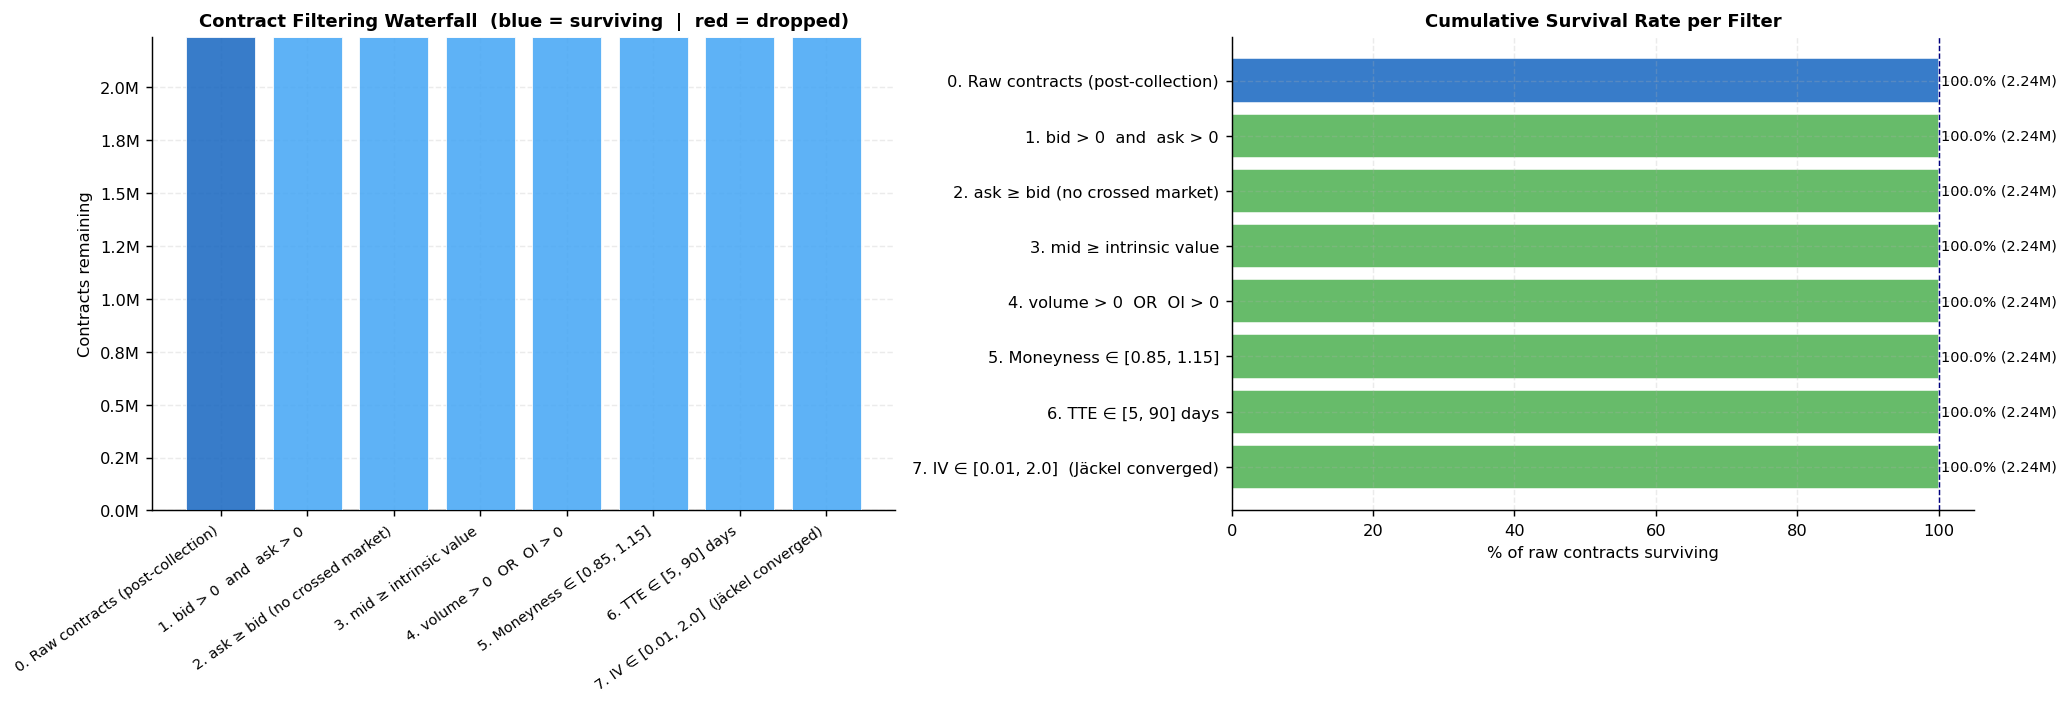

Stage                                            Remaining    Dropped  Survival
--------------------------------------------------------------------------------
0. Raw contracts (post-collection)               2,239,024          0    100.0%
1. bid > 0  and  ask > 0                         2,239,024          0    100.0%
2. ask ≥ bid (no crossed market)                 2,239,024          0    100.0%
3. mid ≥ intrinsic value                         2,239,024          0    100.0%
4. volume > 0  OR  OI > 0                        2,239,024          0    100.0%
5. Moneyness ∈ [0.85, 1.15]                      2,239,024          0    100.0%
6. TTE ∈ [5, 90] days                            2,239,024          0    100.0%
7. IV ∈ [0.01, 2.0]  (Jäckel converged)          2,239,024          0    100.0%


In [5]:
# Reproduce Phase 1.1 filters on the raw iv_data to show survival rates
df_raw = iv_df.copy()

# We track cumulative counts at each stage across ALL tickers
# Raw iv_df already had some pre-filtering; we reproduce the key filters
stages = []

s0 = len(df_raw)
stages.append(('0. Raw contracts (post-collection)', s0, 0))

# Filter 1: bid > 0 and ask > 0
m1 = (df_raw['bid'] > 0) & (df_raw['ask'] > 0)
s1 = m1.sum()
stages.append(('1. bid > 0  and  ask > 0', s1, s0 - s1))
df1 = df_raw[m1].copy()

# Filter 2: ask >= bid (no crossed markets)
m2 = df1['ask'] >= df1['bid']
s2 = m2.sum()
stages.append(('2. ask ≥ bid (no crossed market)', s2, s1 - s2))
df2 = df1[m2].copy()

# Filter 3: price >= intrinsic value
df2['intrinsic'] = np.where(
    df2['type'] == 'c',
    np.maximum(df2['spot'] - df2['strike'], 0),
    np.maximum(df2['strike'] - df2['spot'], 0))
m3 = df2['mid'] >= df2['intrinsic'] - 0.01   # small tolerance
s3 = m3.sum()
stages.append(('3. mid ≥ intrinsic value', s3, s2 - s3))
df3 = df2[m3].copy()

# Filter 4: volume == 0 AND OI == 0 → drop
m4 = ~((df3['volume'] == 0) & (df3['oi'] == 0))
s4 = m4.sum()
stages.append(('4. volume > 0  OR  OI > 0', s4, s3 - s4))
df4 = df3[m4].copy()

# Filter 5: moneyness 0.85 – 1.15
df4['moneyness'] = df4['strike'] / df4['spot']
m5 = (df4['moneyness'] >= 0.85) & (df4['moneyness'] <= 1.15)
s5 = m5.sum()
stages.append(('5. Moneyness ∈ [0.85, 1.15]', s5, s4 - s5))
df5 = df4[m5].copy()

# Filter 6: TTE 5–90 days
m6 = (df5['tte'] >= 5/365) & (df5['tte'] <= 90/365)
s6 = m6.sum()
stages.append(('6. TTE ∈ [5, 90] days', s6, s5 - s6))
df6 = df5[m6].copy()

# Filter 7: IV valid (already computed, just confirm)
m7 = df6['iv'].between(0.01, 2.0)
s7 = m7.sum()
stages.append(('7. IV ∈ [0.01, 2.0]  (Jäckel converged)', s7, s6 - s7))

# ── Waterfall chart ────────────────────────────────────────────────────────
fig, (ax_wf, ax_pct) = plt.subplots(1, 2, figsize=(16, 5.5))

labels  = [s[0] for s in stages]
counts  = [s[1] for s in stages]
dropped = [s[2] for s in stages]

# Build waterfall: running total bar + drop segments
x = np.arange(len(stages))
bar_colors = ['#2196F3'] + ['#F44336'] * (len(stages) - 1)
running = counts[0]
bottoms = [0]
bar_vals = [counts[0]]
for i in range(1, len(stages)):
    bottoms.append(counts[i])
    bar_vals.append(counts[i])

# Plot surviving contracts as a connected step-down
ax_wf.bar(x, counts, color=['#1565C0'] + ['#42A5F5']*(len(stages)-1),
          edgecolor='white', linewidth=0.5, zorder=3, alpha=0.85)
# Overlay drop amounts in red
for i in range(1, len(stages)):
    drop = counts[i-1] - counts[i]
    ax_wf.bar(x[i], drop, bottom=counts[i], color='#EF5350', alpha=0.6,
              edgecolor='white', zorder=4)
    if drop > 0:
        ax_wf.text(x[i], counts[i] + drop/2, f'-{drop:,.0f}',
                   ha='center', va='center', fontsize=7, color='white', fontweight='bold')

ax_wf.set_xticks(x)
ax_wf.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
ax_wf.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1e6:.1f}M'))
ax_wf.set_ylabel('Contracts remaining')
ax_wf.set_title('Contract Filtering Waterfall  (blue = surviving  |  red = dropped)')

# ── Pct survival bar ───────────────────────────────────────────────────────
pct = [c / counts[0] * 100 for c in counts]
colors_pct = ['#1565C0'] + [('#4CAF50' if p > 50 else '#FF9800') for p in pct[1:]]
ax_pct.barh(labels[::-1], pct[::-1], color=colors_pct[::-1], alpha=0.85, edgecolor='white')
ax_pct.set_xlabel('% of raw contracts surviving')
ax_pct.set_title('Cumulative Survival Rate per Filter')
ax_pct.axvline(100, color='navy', lw=0.8, ls='--')
for i, (p, c) in enumerate(zip(pct[::-1], counts[::-1])):
    ax_pct.text(p + 0.3, i, f'{p:.1f}% ({c/1e6:.2f}M)', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# ── Print table ────────────────────────────────────────────────────────────
print(f"{'Stage':<45} {'Remaining':>12} {'Dropped':>10} {'Survival':>9}")
print('-' * 80)
for label, cnt, drop in stages:
    pct_surv = cnt / stages[0][1] * 100
    print(f"{label:<45} {cnt:>12,.0f} {drop:>10,.0f} {pct_surv:>8.1f}%")

## 3 · Underlying Prices, Realized Vol & Macro

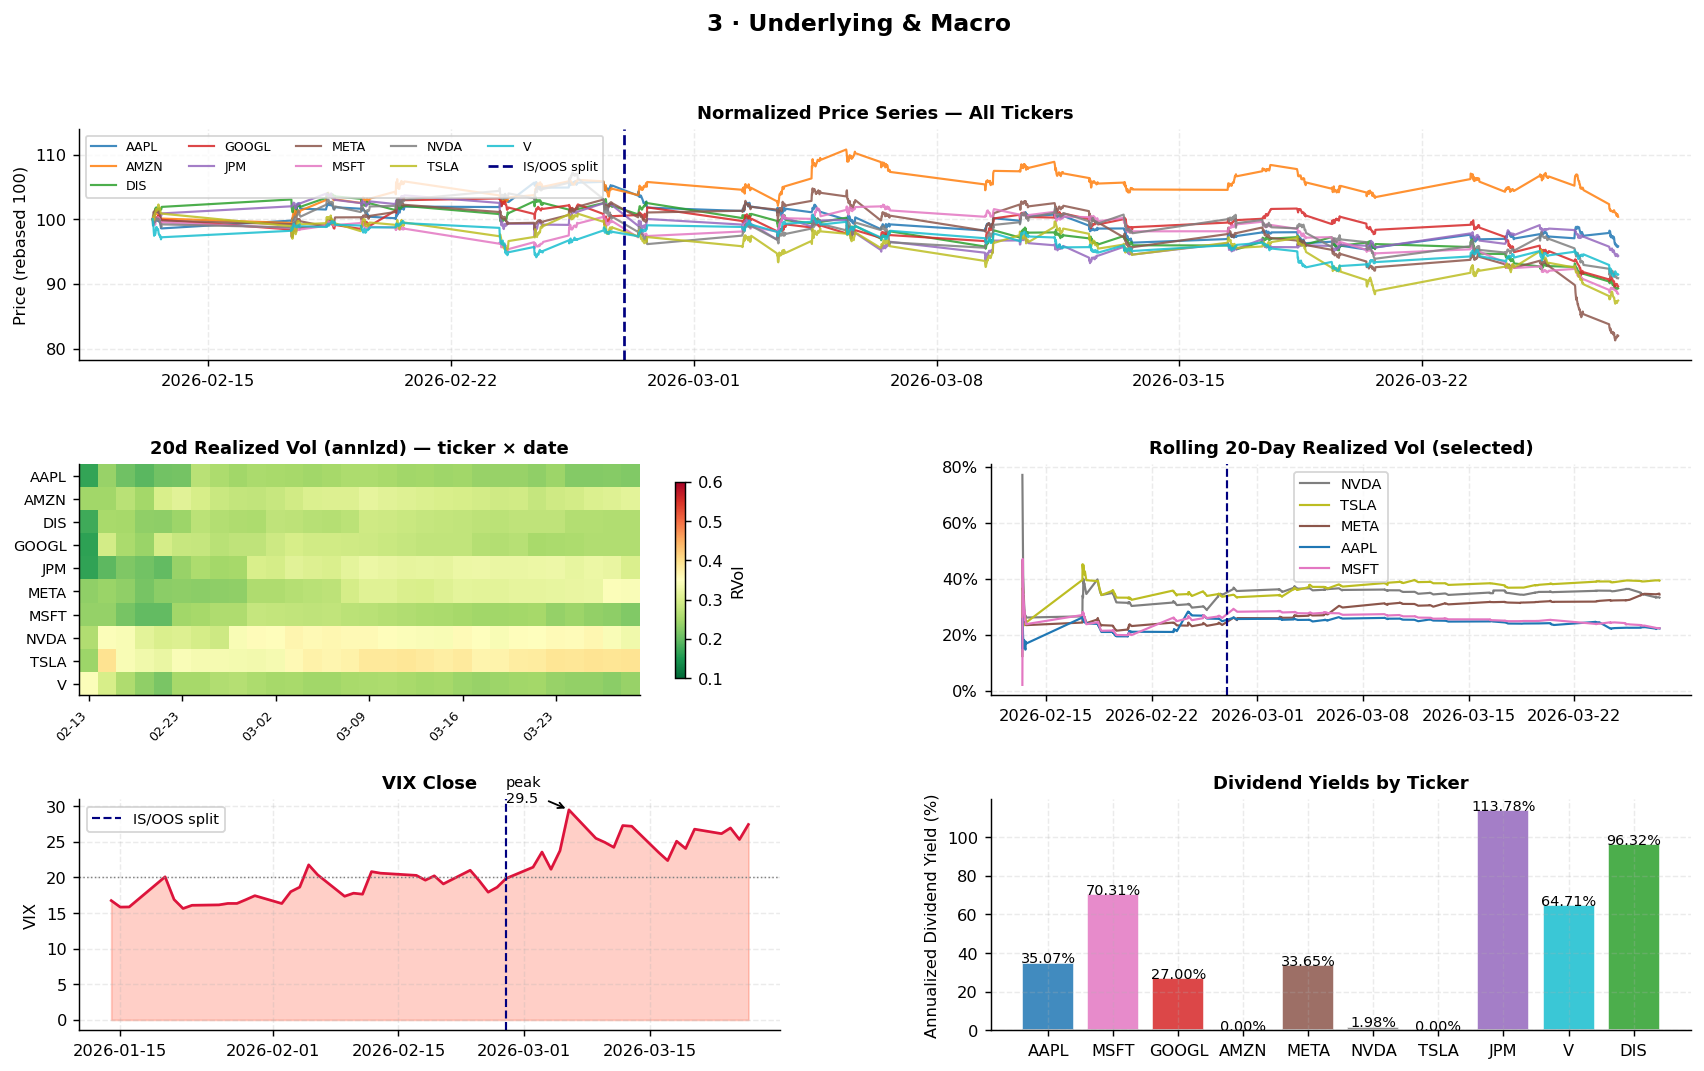

VIX: min=15.6  mean=20.8  max=29.5
VIX peak date: 2026-03-06
rf_rate: 3.528% (annlzd continuous)

⚠  DIS / JPM / V spot prices are CONSTANT in intraday_greeks → no intraday variation captured for these tickers


In [6]:
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# ── 3a: Normalized price series ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
for tkr in TICKERS:
    sub = stock_df[stock_df['ticker']==tkr].sort_values('timestamp')
    close = sub['close'].values
    ax1.plot(sub['timestamp'], close/close[0]*100, lw=1.2,
             label=tkr, color=TICKER_CLR[tkr], alpha=0.85)
ax1.axvline(IS_END, color='navy', lw=1.5, ls='--', label='IS/OOS split')
ax1.axhspan(ax1.get_ylim()[0] if ax1.get_ylim()[0] > 0 else 80,
            ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0 else 120,
            alpha=0)
ax1.set_ylabel('Price (rebased 100)')
ax1.set_title('Normalized Price Series — All Tickers')
ax1.legend(fontsize=7, ncol=5, loc='upper left')

# ── 3b: Realized vol heatmap (ticker × date) ─────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
stock_df['date'] = stock_df['timestamp'].dt.date
rvol = (stock_df.groupby(['ticker','date'])['realized_vol_20d']
        .last().unstack('date'))
im = ax2.imshow(rvol.values, aspect='auto', cmap='RdYlGn_r', vmin=0.10, vmax=0.60)
ax2.set_xticks(np.arange(0, rvol.shape[1], 5))
ax2.set_xticklabels([str(d).replace('2026-','') for d in rvol.columns[::5]],
                    rotation=45, ha='right', fontsize=7)
ax2.set_yticks(np.arange(len(rvol.index)))
ax2.set_yticklabels(rvol.index, fontsize=8)
ax2.set_title('20d Realized Vol (annlzd) — ticker × date')
plt.colorbar(im, ax=ax2, shrink=0.85, label='RVol')
ax2.grid(False)

# ── 3c: Realized vol time series (select tickers) ─────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
for tkr in ['NVDA','TSLA','META','AAPL','MSFT']:
    sub = stock_df[stock_df['ticker']==tkr].sort_values('timestamp')
    ax3.plot(sub['timestamp'], sub['realized_vol_20d'], lw=1.2,
             label=tkr, color=TICKER_CLR[tkr])
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax3.axvline(IS_END, color='navy', lw=1.2, ls='--')
ax3.legend(fontsize=8); ax3.set_title('Rolling 20-Day Realized Vol (selected)')

# ── 3d: VIX time series ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.fill_between(ext_df['date'], ext_df['vix_close'], alpha=0.3, color='tomato')
ax4.plot(ext_df['date'], ext_df['vix_close'], color='crimson', lw=1.5)
ax4.axvline(IS_END, color='navy', lw=1.2, ls='--', label='IS/OOS split')
ax4.axhline(20, color='gray', lw=0.8, ls=':')
ax4.set_ylabel('VIX'); ax4.set_title('VIX Close')
vix_max_date = ext_df.loc[ext_df['vix_close'].idxmax(), 'date']
ax4.annotate(f"peak\n{ext_df['vix_close'].max():.1f}",
             xy=(vix_max_date, ext_df['vix_close'].max()),
             xytext=(vix_max_date - pd.Timedelta('7d'), ext_df['vix_close'].max()+1),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=8)
ax4.legend(fontsize=8)

# ── 3e: Div yields bar chart ──────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
div_cols = [c for c in ext_df.columns if c.startswith('div_yield_')]
div_tickers = [c.replace('div_yield_','') for c in div_cols]
div_vals = ext_df[div_cols].iloc[-1].values
colors_div = [TICKER_CLR.get(t,'gray') for t in div_tickers]
ax5.bar(div_tickers, div_vals*100, color=colors_div, alpha=0.85, edgecolor='white')
ax5.set_ylabel('Annualized Dividend Yield (%)'); ax5.set_title('Dividend Yields by Ticker')
for i,(t,v) in enumerate(zip(div_tickers, div_vals)):
    ax5.text(i, v*100+0.02, f'{v*100:.2f}%', ha='center', fontsize=8)

plt.suptitle('3 · Underlying & Macro', fontsize=13, fontweight='bold')
plt.show()

print(f'VIX: min={ext_df["vix_close"].min():.1f}  mean={ext_df["vix_close"].mean():.1f}  max={ext_df["vix_close"].max():.1f}')
print(f'VIX peak date: {vix_max_date.date()}')
print(f'rf_rate: {ext_df["rf_rate"].mean()*100:.3f}% (annlzd continuous)')
print('\n⚠  DIS / JPM / V spot prices are CONSTANT in intraday_greeks → no intraday variation captured for these tickers')

## 4 · Heston Calibration Quality

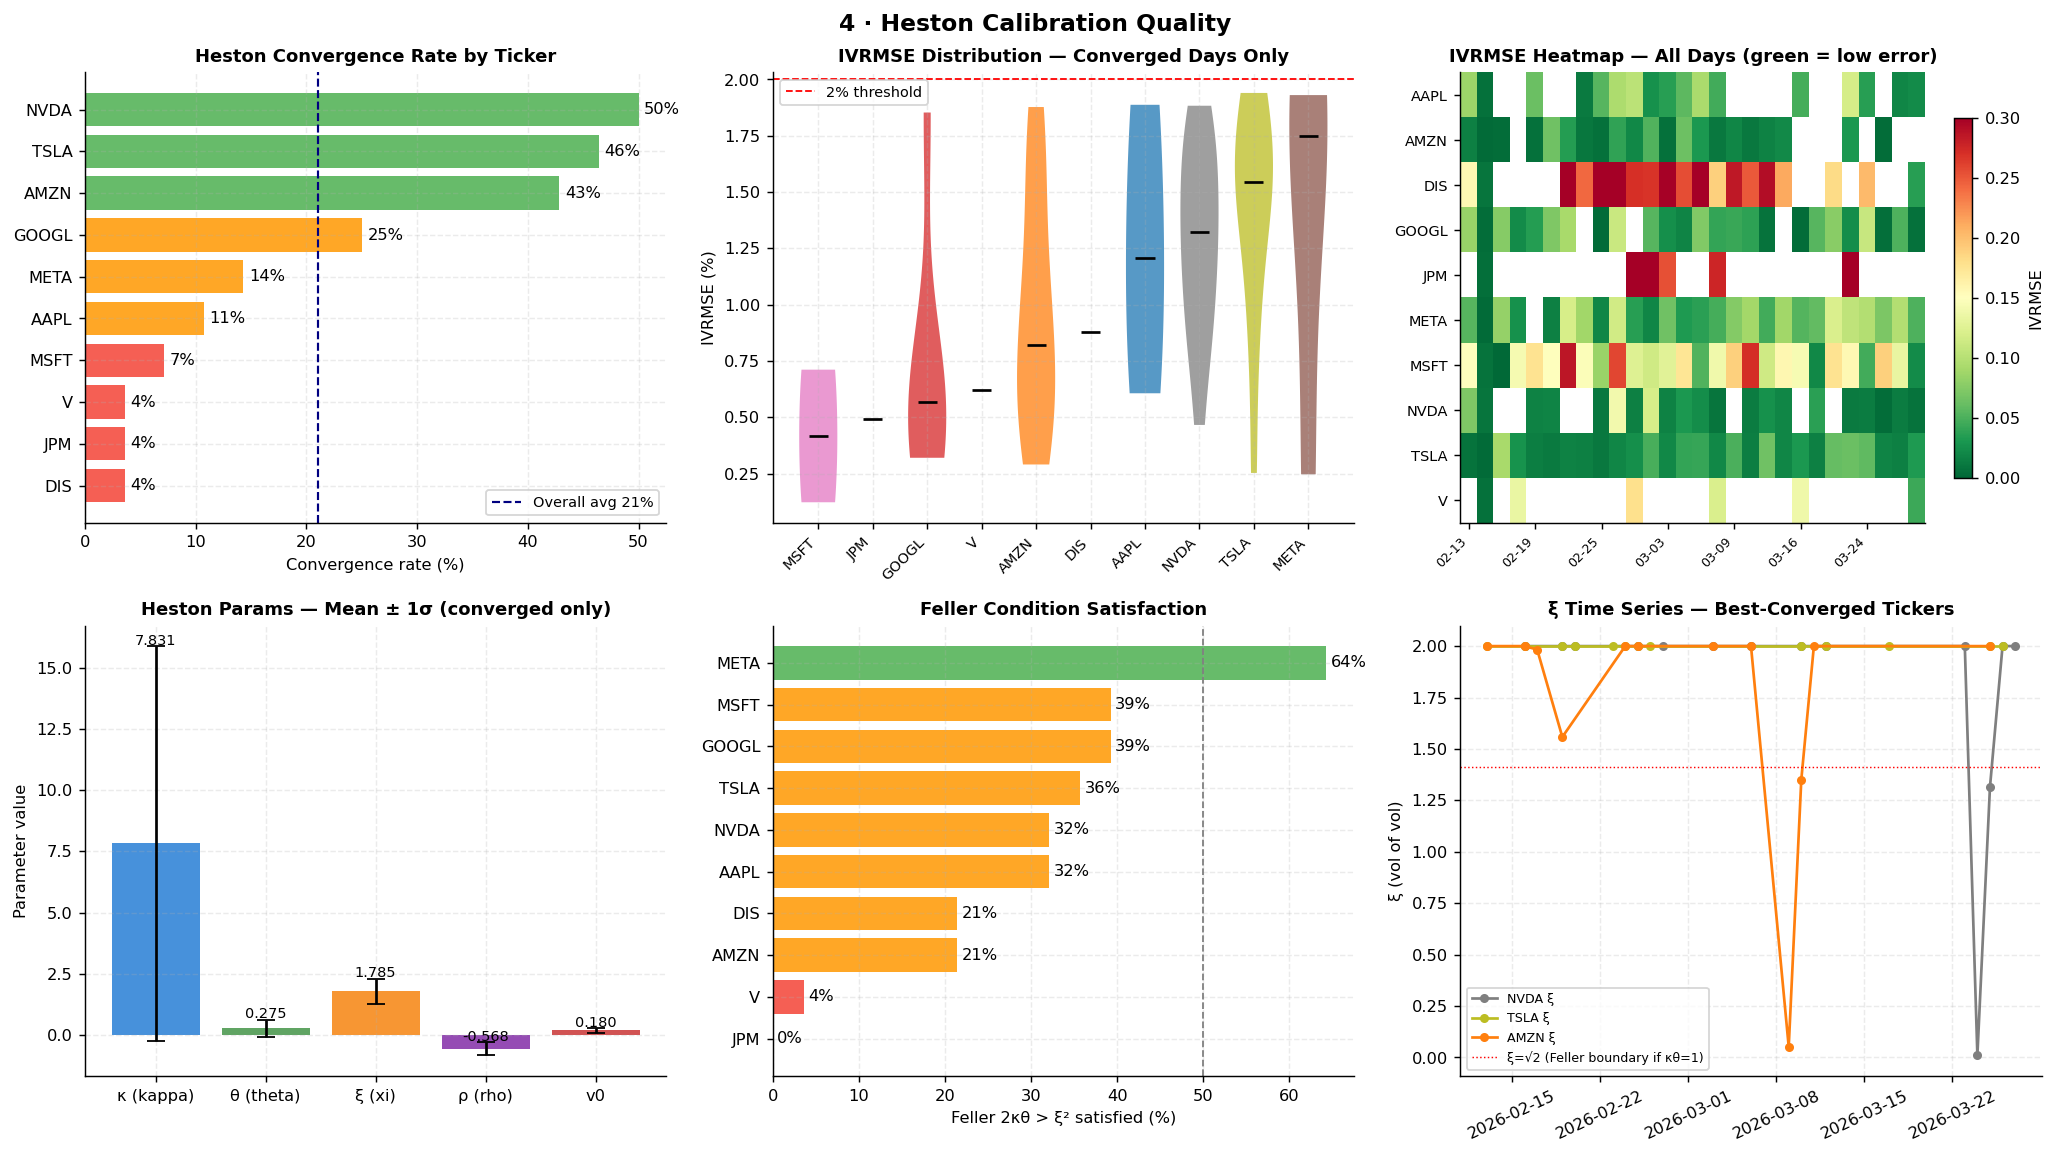

Overall convergence rate : 20.7%  (58/280 ticker-days)
Feller satisfied overall : 28.9%
IVRMSE > 2% (converged)  : 0.0% of converged days
xi at upper bound (2.0)  : 0 rows — optimizer hitting boundary
rho at lower bound (-0.01): 0 rows

⚠  CRITICAL: Low overall convergence (21%) is a calibration pipeline concern.
   DIS/JPM/V each converge <4% of days — Heston likely not fitting sparse option chains.
   NVDA/TSLA/AMZN are the only well-calibrated tickers (>42% convergence).
   Feller violated 71% of all days → variance process can theoretically hit zero.


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# ── 4a: Convergence rate per ticker ──────────────────────────────────────
ax = axes[0]
conv_rate = heston_df.groupby('ticker')['converged'].mean().sort_values()
bar_c = ['#4CAF50' if v >= 0.3 else '#FF9800' if v >= 0.1 else '#F44336'
         for v in conv_rate.values]
ax.barh(conv_rate.index, conv_rate.values * 100, color=bar_c, alpha=0.85)
ax.axvline(21, color='navy', lw=1.2, ls='--', label='Overall avg 21%')
ax.set_xlabel('Convergence rate (%)'); ax.set_title('Heston Convergence Rate by Ticker')
for i, v in enumerate(conv_rate.values):
    ax.text(v*100+0.5, i, f'{v*100:.0f}%', va='center', fontsize=9)
ax.legend(fontsize=8)

# ── 4b: IVRMSE distribution per ticker (converged only) ───────────────────
ax = axes[1]
conv_only = heston_df[heston_df['converged'] == True]
ticker_order = conv_only.groupby('ticker')['ivrmse'].median().sort_values().index
data_iv = [conv_only[conv_only['ticker']==t]['ivrmse'].dropna().values * 100
           for t in ticker_order]
vp = ax.violinplot(data_iv, positions=range(len(ticker_order)),
                   widths=0.7, showmedians=True, showextrema=False)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(TICKER_CLR[ticker_order[i]])
    body.set_alpha(0.75)
vp['cmedians'].set_color('k')
ax.axhline(2.0, color='red', lw=1.0, ls='--', label='2% threshold')
ax.set_xticks(range(len(ticker_order)))
ax.set_xticklabels(ticker_order, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('IVRMSE (%)'); ax.set_title('IVRMSE Distribution — Converged Days Only')
ax.legend(fontsize=8)

# ── 4c: IVRMSE heatmap all days (ticker × date) ───────────────────────────
ax = axes[2]
heston_df_h = heston_df.copy()
heston_df_h['date_d'] = pd.to_datetime(heston_df_h['date']).dt.date
piv = heston_df_h.pivot_table(index='ticker', columns='date_d', values='ivrmse')
im3 = ax.imshow(piv.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=0.3)
ax.set_xticks(np.arange(0, piv.shape[1], 4))
ax.set_xticklabels([str(d).replace('2026-','') for d in piv.columns[::4]],
                   rotation=45, ha='right', fontsize=7)
ax.set_yticks(np.arange(len(piv.index)))
ax.set_yticklabels(piv.index, fontsize=8)
ax.set_title('IVRMSE Heatmap — All Days (green = low error)')
plt.colorbar(im3, ax=ax, shrink=0.8, label='IVRMSE')
ax.grid(False)

# ── 4d: Parameter distributions (converged only) ─────────────────────────
ax = axes[3]
param_stats = conv_only[['kappa','theta','xi','rho','v0']].describe().T[['mean','std','min','max']]
x_params = np.arange(5)
param_names_d = ['κ (kappa)','θ (theta)','ξ (xi)','ρ (rho)','v0']
means = conv_only[['kappa','theta','xi','rho','v0']].mean().values
stds  = conv_only[['kappa','theta','xi','rho','v0']].std().values
ax.bar(x_params, means, yerr=stds, capsize=5,
       color=['#1976D2','#388E3C','#F57C00','#7B1FA2','#C62828'], alpha=0.8)
ax.set_xticks(x_params)
ax.set_xticklabels(param_names_d, fontsize=9)
ax.set_title('Heston Params — Mean ± 1σ (converged only)')
ax.set_ylabel('Parameter value')
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.05, f'{m:.3f}', ha='center', fontsize=8)

# ── 4e: Feller condition per ticker ──────────────────────────────────────
ax = axes[4]
heston_df_h['feller_bool'] = heston_df_h['feller_ok'].apply(
    lambda x: True if str(x).lower() == 'true' else False)
feller_rate = heston_df_h.groupby('ticker')['feller_bool'].mean().sort_values()
bar_f = ['#4CAF50' if v >= 0.5 else '#FF9800' if v >= 0.2 else '#F44336'
         for v in feller_rate.values]
ax.barh(feller_rate.index, feller_rate.values * 100, color=bar_f, alpha=0.85)
ax.axvline(50, color='gray', lw=1, ls='--')
ax.set_xlabel('Feller 2κθ > ξ² satisfied (%)'); ax.set_title('Feller Condition Satisfaction')
for i, v in enumerate(feller_rate.values):
    ax.text(v*100+0.5, i, f'{v*100:.0f}%', va='center', fontsize=9)

# ── 4f: kappa/xi/rho stability for best tickers ──────────────────────────
ax = axes[5]
best_tickers = ['NVDA','TSLA','AMZN']
for tkr in best_tickers:
    sub = heston_df_h[(heston_df_h['ticker']==tkr) & 
                      (heston_df_h['converged']==True)].sort_values('date_d')
    if len(sub) > 2:
        ax.plot(sub['date_d'], sub['xi'], lw=1.5, 
                label=f'{tkr} ξ', color=TICKER_CLR[tkr], marker='o', ms=4)
ax.axhline(1.41, color='red', lw=0.8, ls=':', label='ξ=√2 (Feller boundary if κθ=1)')
ax.set_ylabel('ξ (vol of vol)'); ax.set_title('ξ Time Series — Best-Converged Tickers')
ax.legend(fontsize=7); ax.tick_params(axis='x', rotation=25)

plt.suptitle('4 · Heston Calibration Quality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Print flags ────────────────────────────────────────────────────────────
overall_conv = heston_df['converged'].mean()
print(f'Overall convergence rate : {overall_conv*100:.1f}%  ({int(heston_df["converged"].sum())}/{len(heston_df)} ticker-days)')
print(f'Feller satisfied overall : {heston_df_h["feller_bool"].mean()*100:.1f}%')
print(f'IVRMSE > 2% (converged)  : {(conv_only["ivrmse"]>0.02).mean()*100:.1f}% of converged days')
print(f'xi at upper bound (2.0)  : {(heston_df_h["xi"]==2.0).sum()} rows — optimizer hitting boundary')
print(f'rho at lower bound (-0.01): {(heston_df_h["rho"]==-0.01).sum()} rows')
print()
print('⚠  CRITICAL: Low overall convergence (21%) is a calibration pipeline concern.')
print('   DIS/JPM/V each converge <4% of days — Heston likely not fitting sparse option chains.')
print('   NVDA/TSLA/AMZN are the only well-calibrated tickers (>42% convergence).')
print('   Feller violated 71% of all days → variance process can theoretically hit zero.')

## 5 · IV Surface — ATM IV, Skew & Butterfly

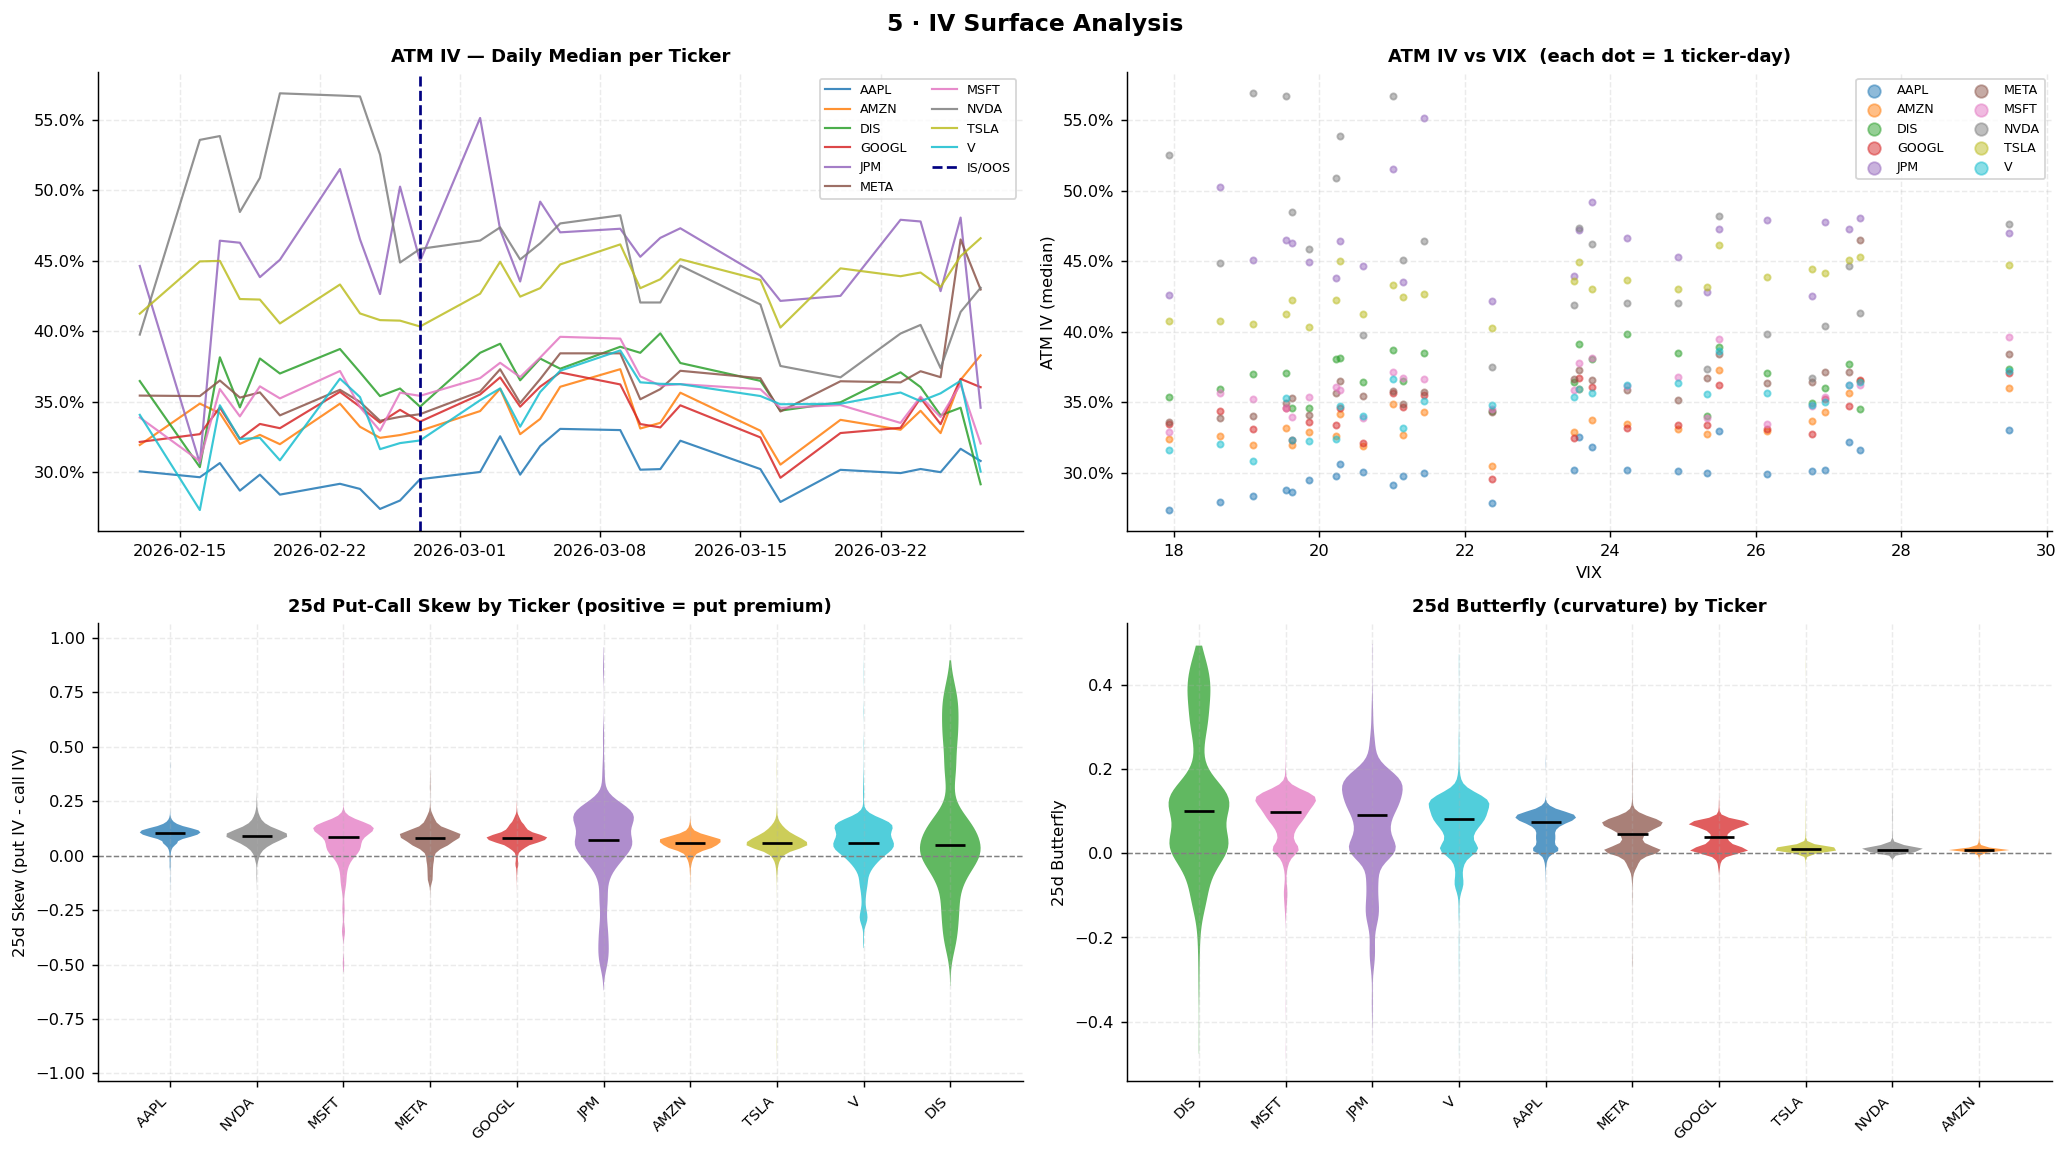

  AAPL  : ATM IV mean=30.1%  min=27.4%  max=33.1%
  AMZN  : ATM IV mean=33.9%  min=30.5%  max=38.3%
  DIS   : ATM IV mean=36.3%  min=29.1%  max=39.8%
  GOOGL : ATM IV mean=34.2%  min=29.6%  max=37.1%
  JPM   : ATM IV mean=45.4%  min=30.6%  max=55.1%
  META  : ATM IV mean=36.5%  min=33.6%  max=46.5%
  MSFT  : ATM IV mean=35.5%  min=30.8%  max=39.6%
  NVDA  : ATM IV mean=46.0%  min=36.7%  max=56.9%
  TSLA  : ATM IV mean=43.2%  min=40.3%  max=46.6%
  V     : ATM IV mean=34.4%  min=27.3%  max=38.6%


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# ── 5a: ATM IV time series per ticker ─────────────────────────────────────
ax = axes[0,0]
surf_day = surf_df.copy()
surf_day['date'] = surf_day['timestamp'].dt.date
atm_daily = (surf_day.groupby(['ticker','date'])['atm_iv']
             .median().reset_index())
for tkr in TICKERS:
    sub = atm_daily[atm_daily['ticker']==tkr].sort_values('date')
    ax.plot(sub['date'], sub['atm_iv'], lw=1.2, alpha=0.85,
            label=tkr, color=TICKER_CLR[tkr])
ax.axvline(IS_END.date(), color='navy', lw=1.5, ls='--', label='IS/OOS')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.set_title('ATM IV — Daily Median per Ticker')
ax.legend(fontsize=7, ncol=2)

# ── 5b: ATM IV vs VIX scatter ─────────────────────────────────────────────
ax = axes[0,1]
ext_df['date_d'] = ext_df['date'].dt.date
atm_v_vix = atm_daily.merge(
    ext_df[['date_d','vix_close']].rename(columns={'date_d':'date'}),
    on='date', how='inner')
for tkr in TICKERS:
    sub = atm_v_vix[atm_v_vix['ticker']==tkr]
    ax.scatter(sub['vix_close'], sub['atm_iv'], s=12, alpha=0.5,
               label=tkr, color=TICKER_CLR[tkr])
ax.set_xlabel('VIX'); ax.set_ylabel('ATM IV (median)')
ax.set_title('ATM IV vs VIX  (each dot = 1 ticker-day)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.legend(fontsize=7, ncol=2, markerscale=2)

# ── 5c: Skew 25d distribution ─────────────────────────────────────────────
ax = axes[1,0]
skew_valid = surf_df.dropna(subset=['skew_25d'])
skew_valid = skew_valid[skew_valid['skew_25d'].between(-1, 1)]
skew_by_t = skew_valid.groupby('ticker')['skew_25d']
medians_sk = skew_by_t.median().sort_values(ascending=False)
vp_sk = ax.violinplot(
    [skew_valid[skew_valid['ticker']==t]['skew_25d'].values for t in medians_sk.index],
    positions=range(len(medians_sk)), widths=0.7, showmedians=True, showextrema=False)
for i, body in enumerate(vp_sk['bodies']):
    body.set_facecolor(TICKER_CLR[medians_sk.index[i]])
    body.set_alpha(0.75)
vp_sk['cmedians'].set_color('k')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xticks(range(len(medians_sk)))
ax.set_xticklabels(medians_sk.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('25d Skew (put IV - call IV)')
ax.set_title('25d Put-Call Skew by Ticker (positive = put premium)')

# ── 5d: Butterfly 25d distribution ────────────────────────────────────────
ax = axes[1,1]
butt_valid = surf_df.dropna(subset=['butterfly_25d'])
butt_valid = butt_valid[butt_valid['butterfly_25d'].between(-0.5, 0.5)]
butt_by_t  = butt_valid.groupby('ticker')['butterfly_25d']
medians_bt = butt_by_t.median().sort_values(ascending=False)
vp_bt = ax.violinplot(
    [butt_valid[butt_valid['ticker']==t]['butterfly_25d'].values for t in medians_bt.index],
    positions=range(len(medians_bt)), widths=0.7, showmedians=True, showextrema=False)
for i, body in enumerate(vp_bt['bodies']):
    body.set_facecolor(TICKER_CLR[medians_bt.index[i]])
    body.set_alpha(0.75)
vp_bt['cmedians'].set_color('k')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xticks(range(len(medians_bt)))
ax.set_xticklabels(medians_bt.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('25d Butterfly')
ax.set_title('25d Butterfly (curvature) by Ticker')

plt.suptitle('5 · IV Surface Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print
for tkr in TICKERS:
    sub = atm_daily[atm_daily['ticker']==tkr]
    print(f'  {tkr:6s}: ATM IV mean={sub["atm_iv"].mean()*100:.1f}%  '
          f'min={sub["atm_iv"].min()*100:.1f}%  max={sub["atm_iv"].max()*100:.1f}%')

## 6 · Signal Analysis — S1, S2, S4

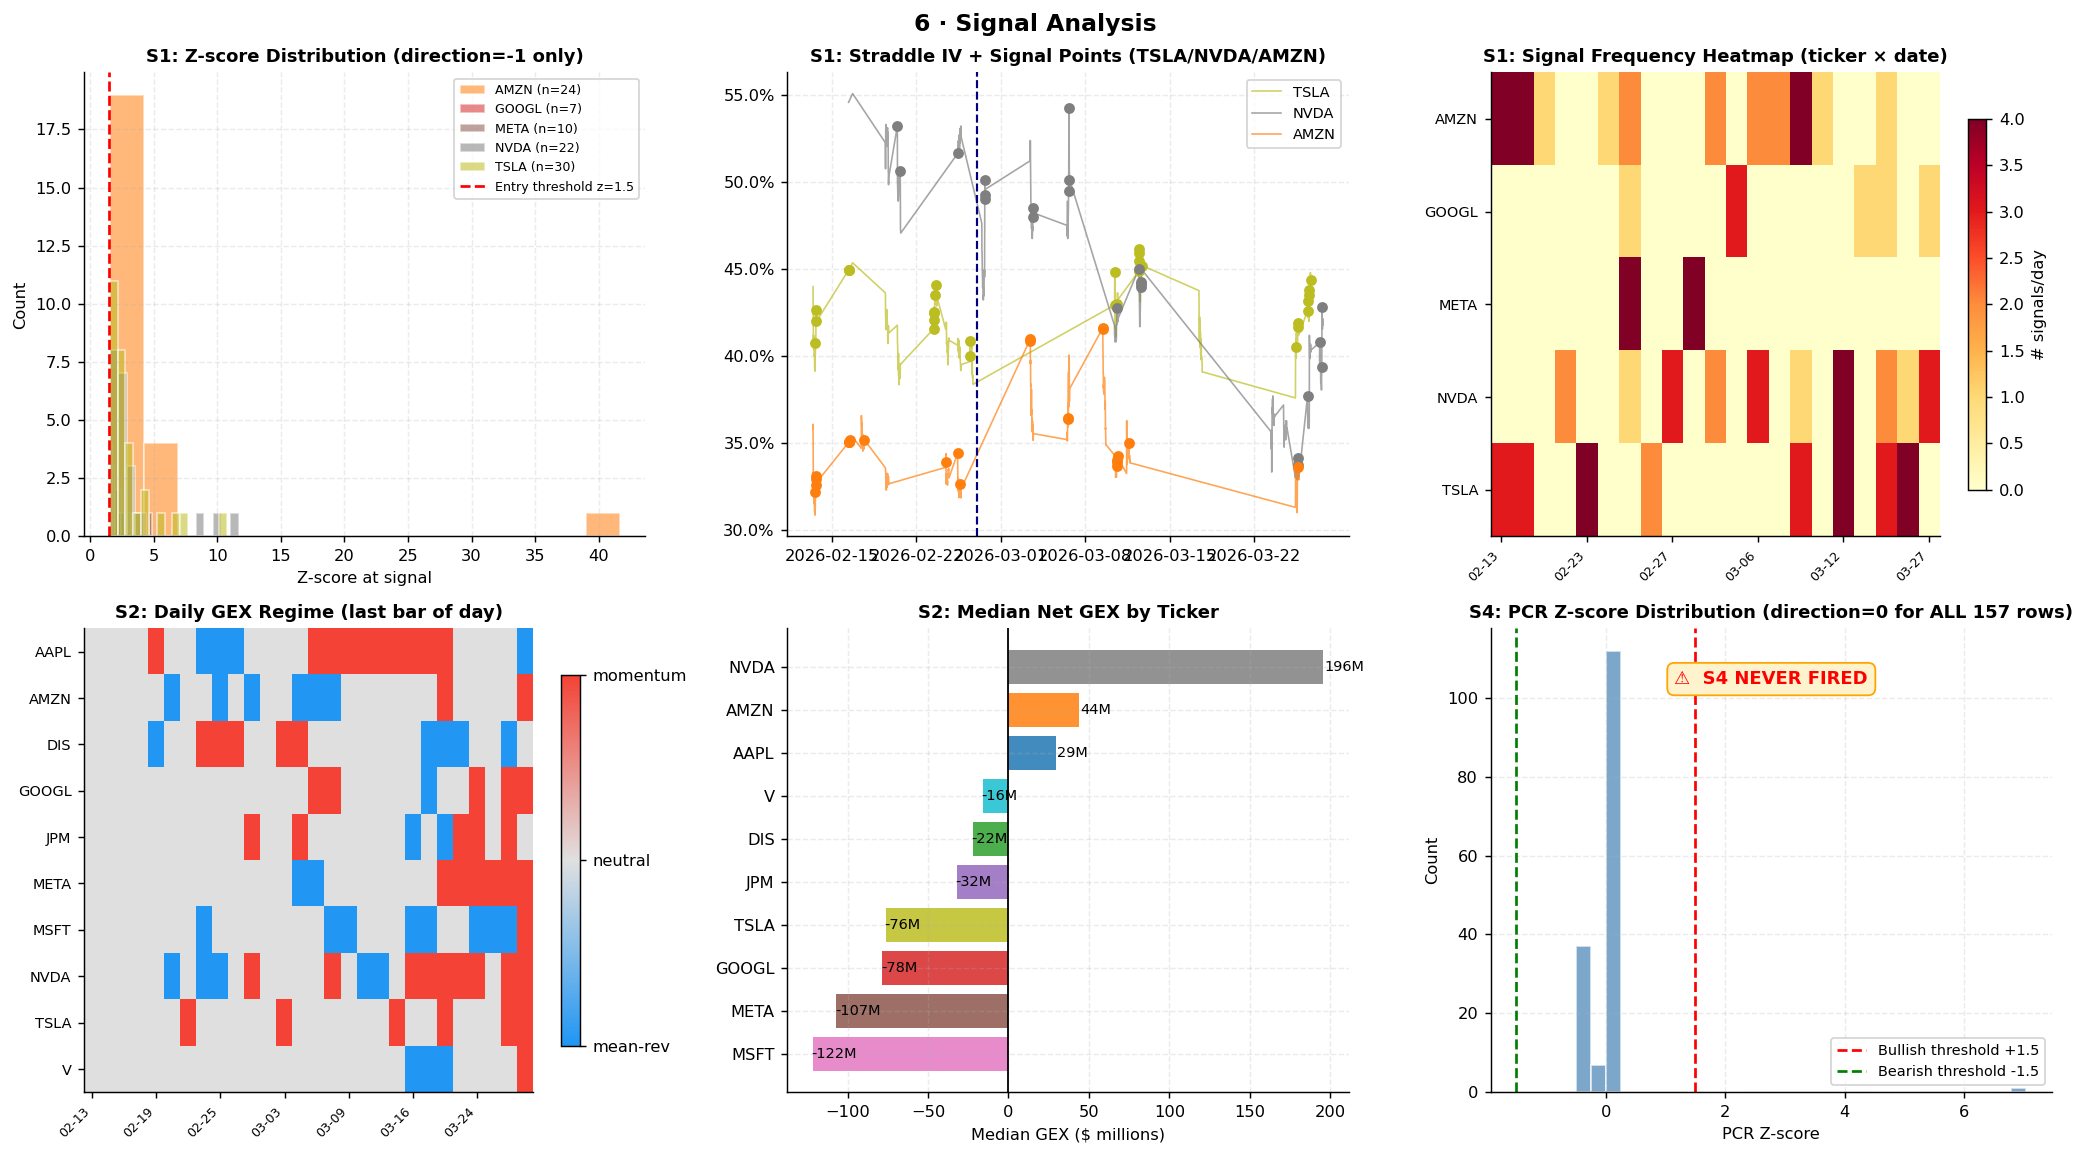

S1 total rows : 1,552  |  signals fired: 93 (all short)
S1 by ticker  : {'TSLA': 30, 'AMZN': 24, 'NVDA': 22, 'META': 10, 'GOOGL': 7}
S1 spread_flag True rate: 38.0% (gate passes only when spread > median)
S2 regimes    : {'neutral': 5333, 'momentum': 1456, 'mean_reversion': 1187}
S4 max |pcr_z|: 7.038  — never crosses ±1.5 threshold

⚠  S4 direction is 0 for all 157 rows. pcr_z max = 7.038 (< 1.5).
   S4 may also require gex_corroboration alignment — check signal_s4.py logic.


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# ── 6a: S1 z-score distribution per firing ticker ─────────────────────────
ax = axes[0,0]
active = sig1_df[sig1_df['direction'] == -1]
for tkr in active['ticker'].unique():
    sub = active[active['ticker']==tkr]['z_score']
    ax.hist(sub, bins=15, alpha=0.55, label=f'{tkr} (n={len(sub)})',
            color=TICKER_CLR[tkr], edgecolor='white')
ax.axvline(1.5, color='red', lw=1.5, ls='--', label='Entry threshold z=1.5')
ax.set_xlabel('Z-score at signal'); ax.set_ylabel('Count')
ax.set_title('S1: Z-score Distribution (direction=-1 only)')
ax.legend(fontsize=7)

# ── 6b: S1 straddle IV time series + signal dots ──────────────────────────
ax = axes[0,1]
for tkr in ['TSLA','NVDA','AMZN']:
    sub = sig1_df[sig1_df['ticker']==tkr].sort_values('timestamp')
    ax.plot(sub['timestamp'], sub['straddle_iv'], lw=0.9, 
            alpha=0.7, label=tkr, color=TICKER_CLR[tkr])
    signals = sub[sub['direction']==-1]
    ax.scatter(signals['timestamp'], signals['straddle_iv'], 
               s=25, color=TICKER_CLR[tkr], zorder=5)
ax.axvline(IS_END, color='navy', lw=1.2, ls='--')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.set_title('S1: Straddle IV + Signal Points (TSLA/NVDA/AMZN)')
ax.legend(fontsize=8)

# ── 6c: S1 signal frequency heatmap (ticker × date) ──────────────────────
ax = axes[0,2]
sig1_df['signal_date'] = sig1_df['timestamp'].dt.date
sig_heat = (sig1_df[sig1_df['direction']==-1]
            .groupby(['ticker','signal_date']).size()
            .unstack('signal_date').fillna(0))
if not sig_heat.empty:
    im6c = ax.imshow(sig_heat.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=4)
    ax.set_xticks(np.arange(0, sig_heat.shape[1], 4))
    ax.set_xticklabels([str(d).replace('2026-','') for d in sig_heat.columns[::4]],
                       rotation=45, ha='right', fontsize=7)
    ax.set_yticks(np.arange(len(sig_heat.index)))
    ax.set_yticklabels(sig_heat.index, fontsize=8)
    plt.colorbar(im6c, ax=ax, shrink=0.8, label='# signals/day')
ax.set_title('S1: Signal Frequency Heatmap (ticker × date)')
ax.grid(False)

# ── 6d: S2 regime heatmap ─────────────────────────────────────────────────
ax = axes[1,0]
regime_map = {'momentum': 1, 'neutral': 0, 'mean_reversion': -1}
sig2_df['regime_num'] = sig2_df['regime'].map(regime_map)
sig2_df['signal_date2'] = sig2_df['timestamp'].dt.date
reg_heat = (sig2_df.groupby(['ticker','signal_date2'])['regime_num']
            .last().unstack('signal_date2').fillna(0))
cmap_reg = LinearSegmentedColormap.from_list('reg', ['#2196F3','#E0E0E0','#F44336'])
im6d = ax.imshow(reg_heat.values, aspect='auto', cmap=cmap_reg, vmin=-1, vmax=1)
ax.set_xticks(np.arange(0, reg_heat.shape[1], 4))
ax.set_xticklabels([str(d).replace('2026-','') for d in reg_heat.columns[::4]],
                   rotation=45, ha='right', fontsize=7)
ax.set_yticks(np.arange(len(reg_heat.index)))
ax.set_yticklabels(reg_heat.index, fontsize=8)
cbar = plt.colorbar(im6d, ax=ax, shrink=0.8)
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(['mean-rev', 'neutral', 'momentum'])
ax.set_title('S2: Daily GEX Regime (last bar of day)')
ax.grid(False)

# ── 6e: S2 GEX distribution per ticker ───────────────────────────────────
ax = axes[1,1]
gex_by_t = sig2_df.groupby('ticker')['gex_raw'].median().sort_values()
bar_g = [TICKER_CLR[t] for t in gex_by_t.index]
ax.barh(gex_by_t.index, gex_by_t.values / 1e6, color=bar_g, alpha=0.85)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Median GEX ($ millions)'); ax.set_title('S2: Median Net GEX by Ticker')
for i, v in enumerate(gex_by_t.values / 1e6):
    ax.text(v + (1 if v >= 0 else -1), i, f'{v:.0f}M', va='center', fontsize=8)

# ── 6f: S4 PCR — never fired ──────────────────────────────────────────────
ax = axes[1,2]
ax.hist(sig4_df['pcr_z'].dropna(), bins=30, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(1.5, color='red', lw=1.5, ls='--', label='Bullish threshold +1.5')
ax.axvline(-1.5, color='green', lw=1.5, ls='--', label='Bearish threshold -1.5')
ax.set_xlabel('PCR Z-score'); ax.set_ylabel('Count')
ax.set_title('S4: PCR Z-score Distribution (direction=0 for ALL 157 rows)')
ax.legend(fontsize=8)
ax.text(0.5, 0.88, '⚠  S4 NEVER FIRED', transform=ax.transAxes,
        ha='center', fontsize=10, color='red', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', fc='#fff3cd', ec='orange'))

plt.suptitle('6 · Signal Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Stats
print(f'S1 total rows : {len(sig1_df):,}  |  signals fired: {(sig1_df["direction"]==-1).sum()} (all short)')
print(f'S1 by ticker  : {active.groupby("ticker").size().sort_values(ascending=False).to_dict()}')
print(f'S1 spread_flag True rate: {sig1_df["spread_flag"].mean()*100:.1f}% (gate passes only when spread > median)')
print(f'S2 regimes    : {sig2_df["regime"].value_counts().to_dict()}')
print(f'S4 max |pcr_z|: {sig4_df["pcr_z"].abs().max():.3f}  — never crosses ±1.5 threshold')
print(f'\n⚠  S4 direction is 0 for all 157 rows. pcr_z max = {sig4_df["pcr_z"].max():.3f} (< 1.5).')
print('   S4 may also require gex_corroboration alignment — check signal_s4.py logic.')

## 7 · Trade Analytics — Exit Reasons, Hold Times, Gross→Net Waterfall

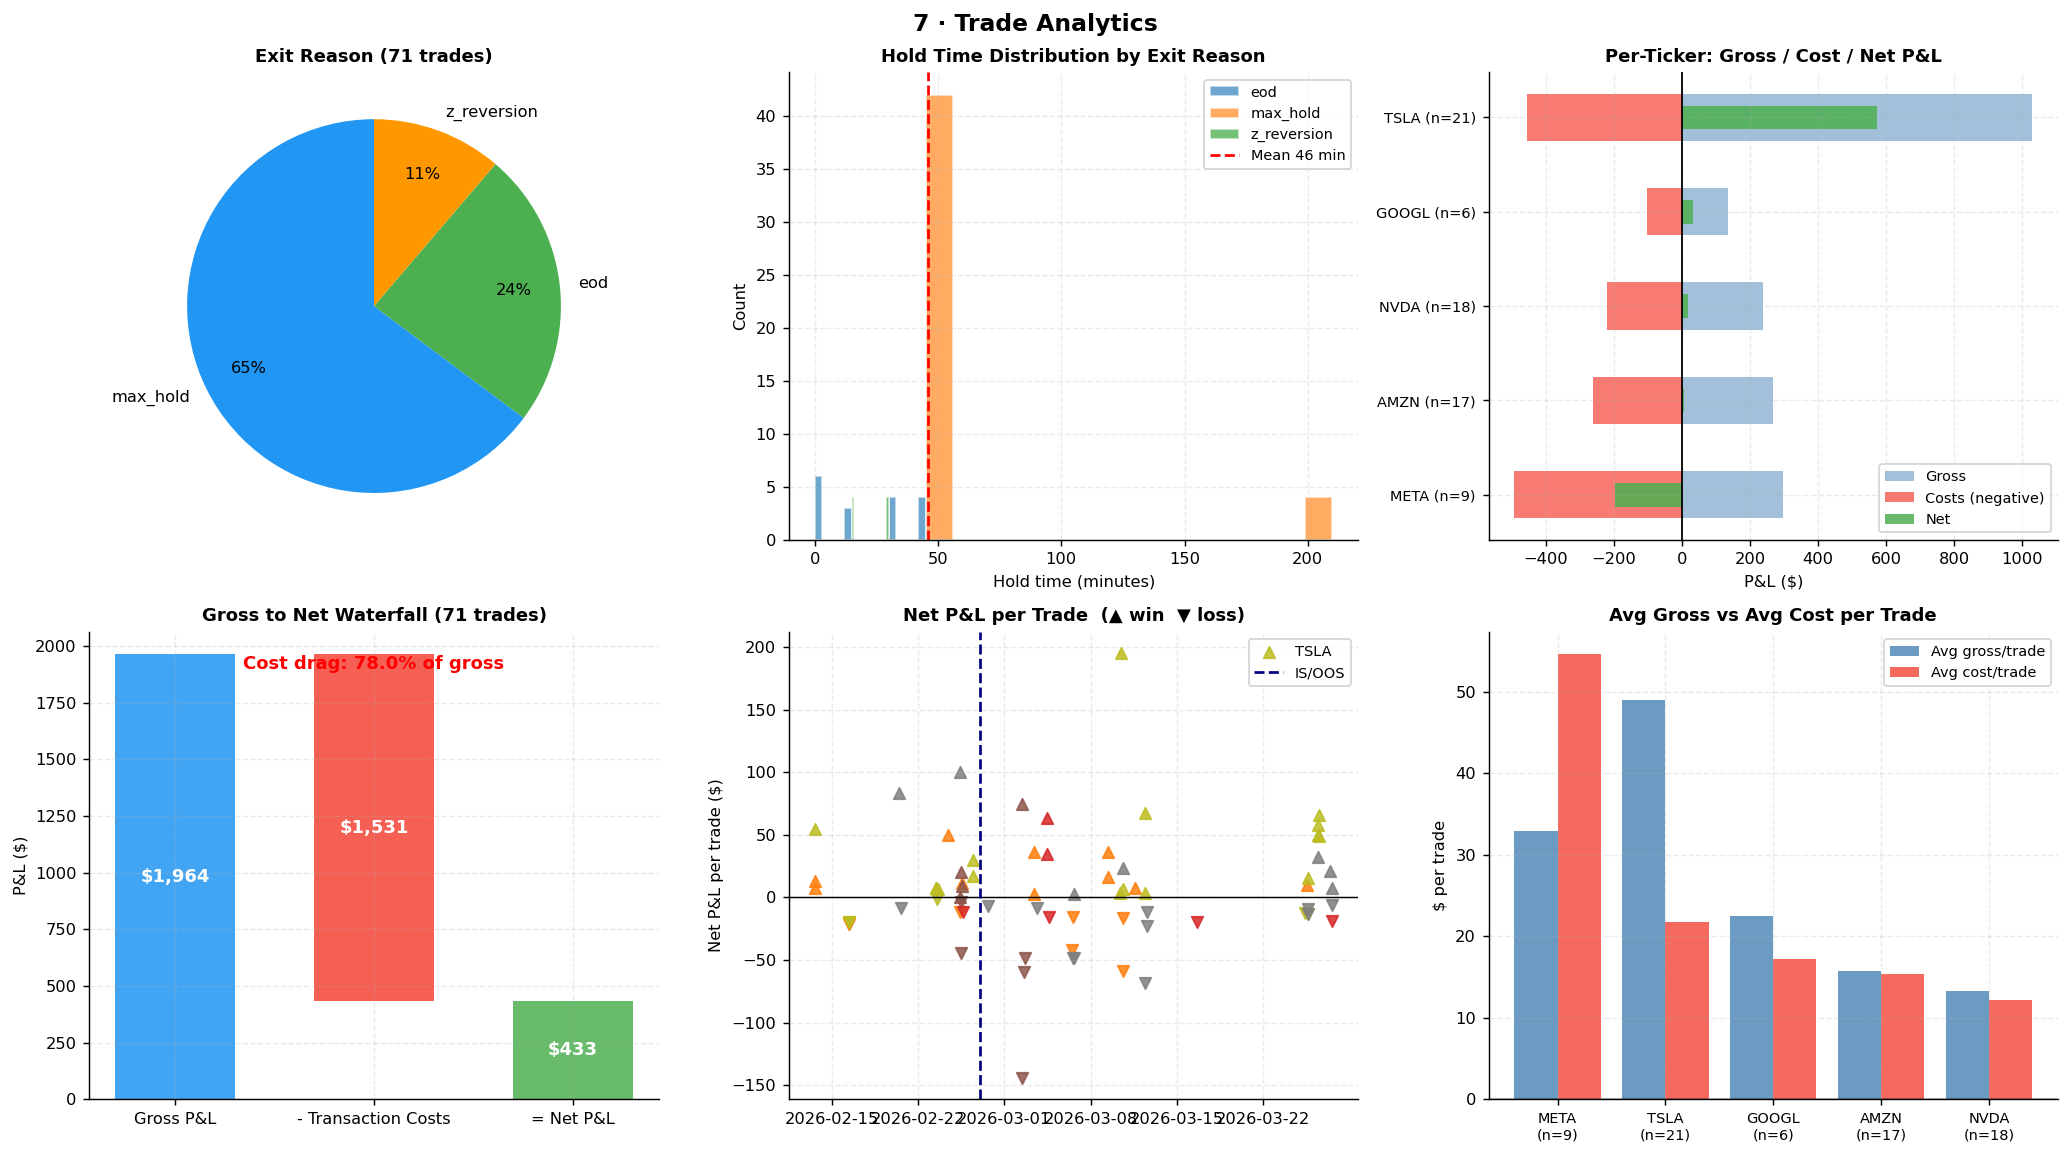

Total trades: 71  |  Win: 39 (54.9%)  |  Loss: 32
Gross: $1,964.04  |  Costs: $1,531.01  |  Net: $433.03
Cost drag: 78.0% of gross P&L eaten by transaction costs
Avg net/trade: $6.10  |  Avg hold: 45.8 min
Max winner: $195.15 (TSLA)  |  Max loser: $-144.19 (META)

Per-ticker net P&L:
  TSLA  : gross=$ 1028.21  cost=$  455.86  net=$  572.35  n=21  win%=76%
  GOOGL : gross=$  134.85  cost=$  102.90  net=$   31.95  n= 6  win%=33%
  NVDA  : gross=$  238.17  cost=$  219.37  net=$   18.80  n=18  win%=39%
  AMZN  : gross=$  266.74  cost=$  261.47  net=$    5.27  n=17  win%=59%
  META  : gross=$  296.07  cost=$  491.41  net=$ -195.34  n= 9  win%=44%


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# ── 7a: Exit reason breakdown ─────────────────────────────────────────────
ax = axes[0,0]
exit_cts = tl_df['exit_reason'].value_counts()
colors_e = ['#2196F3','#4CAF50','#FF9800','#9C27B0'][:len(exit_cts)]
wedges, texts, autotexts = ax.pie(exit_cts.values, labels=exit_cts.index,
                                   colors=colors_e, autopct='%1.0f%%',
                                   startangle=90, pctdistance=0.75,
                                   textprops={'fontsize':9})
ax.set_title('Exit Reason (71 trades)')

# ── 7b: Hold time distribution ────────────────────────────────────────────
ax = axes[0,1]
for reason in tl_df['exit_reason'].unique():
    sub = tl_df[tl_df['exit_reason']==reason]['hold_min']
    ax.hist(sub, bins=15, alpha=0.65, label=reason, edgecolor='white')
ax.set_xlabel('Hold time (minutes)'); ax.set_ylabel('Count')
ax.set_title('Hold Time Distribution by Exit Reason')
ax.axvline(tl_df['hold_min'].mean(), color='red', lw=1.5, ls='--',
           label=f'Mean {tl_df["hold_min"].mean():.0f} min')
ax.legend(fontsize=8)

# ── 7c: Per-ticker net PnL vs cost ────────────────────────────────────────
ax = axes[0,2]
tkr_stats = tl_df.groupby('ticker').agg(
    gross_pnl=('pnl_gross','sum'), cost=('cost','sum'),
    net_pnl=('pnl_net','sum'), n=('pnl_net','count')).reset_index()
tkr_stats = tkr_stats.sort_values('net_pnl', ascending=True)
y_pos = np.arange(len(tkr_stats))
ax.barh(y_pos, tkr_stats['gross_pnl'], color='steelblue', alpha=0.5,
        height=0.5, label='Gross')
ax.barh(y_pos, -tkr_stats['cost'], color='#F44336', alpha=0.7,
        height=0.5, label='Costs (negative)')
ax.barh(y_pos, tkr_stats['net_pnl'], color='#4CAF50', alpha=0.85,
        height=0.25, label='Net')
ax.axvline(0, color='black', lw=1)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row['ticker']} (n={row['n']})" for _, row in tkr_stats.iterrows()], fontsize=8)
ax.set_xlabel('P&L ($)'); ax.set_title('Per-Ticker: Gross / Cost / Net P&L')
ax.legend(fontsize=8)

# ── 7d: Gross→Net waterfall (overall) ─────────────────────────────────────
ax = axes[1,0]
total_gross = tl_df['pnl_gross'].sum()
total_cost  = tl_df['cost'].sum()
total_net   = tl_df['pnl_net'].sum()
wf_labels   = ['Gross P&L', '- Transaction Costs', '= Net P&L']
wf_values   = [total_gross, -total_cost, 0]
wf_bottoms  = [0, total_gross - total_cost, 0]
wf_actual   = [total_gross, total_cost, total_net]
bar_colors  = ['#2196F3', '#F44336', '#4CAF50']
for i, (lbl, val, bot, clr) in enumerate(zip(wf_labels, wf_values, wf_bottoms, bar_colors)):
    if i < 2:
        ax.bar(i, abs(val), bottom=(0 if i==0 else total_net), color=clr, alpha=0.85, width=0.6)
    else:
        ax.bar(i, total_net, color=clr, alpha=0.85, width=0.6)
    ax.text(i, (0 if i==0 else total_net) + abs(val)/2 if i<2 else total_net/2,
            f'${wf_actual[i]:,.0f}', ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')
ax.set_xticks([0,1,2]); ax.set_xticklabels(wf_labels, fontsize=9)
ax.set_ylabel('P&L ($)'); ax.set_title('Gross to Net Waterfall (71 trades)')
cost_pct = total_cost / total_gross * 100
ax.text(0.5, 0.92, f'Cost drag: {cost_pct:.1f}% of gross',
        transform=ax.transAxes, ha='center', fontsize=10,
        color='red', fontweight='bold')

# ── 7e: Win/loss scatter (gross pnl by ticker) ────────────────────────────
ax = axes[1,1]
for tkr in tl_df['ticker'].unique():
    sub = tl_df[tl_df['ticker']==tkr].sort_values('entry_time')
    wins  = sub[sub['pnl_net']>=0]
    losses= sub[sub['pnl_net']< 0]
    ax.scatter(wins['entry_time'],  wins['pnl_net'],  s=40, marker='^',
               color=TICKER_CLR[tkr], alpha=0.85, label=f'{tkr}' if tkr=='TSLA' else '')
    ax.scatter(losses['entry_time'],losses['pnl_net'], s=40, marker='v',
               color=TICKER_CLR[tkr], alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(IS_END, color='navy', lw=1.5, ls='--', label='IS/OOS')
ax.set_ylabel('Net P&L per trade ($)')
ax.set_title('Net P&L per Trade  (▲ win  ▼ loss)')
ax.legend(fontsize=8)

# ── 7f: Cost breakdown by ticker ─────────────────────────────────────────
ax = axes[1,2]
tkr_stats2 = tl_df.groupby('ticker').agg(
    n=('pnl_net','count'), avg_cost=('cost','mean'), 
    total_cost=('cost','sum'), avg_gross=('pnl_gross','mean')).reset_index()
tkr_stats2 = tkr_stats2.sort_values('avg_cost', ascending=False)
x_tc = np.arange(len(tkr_stats2))
bars_ag = ax.bar(x_tc - 0.2, tkr_stats2['avg_gross'], width=0.4, 
                  color='steelblue', alpha=0.8, label='Avg gross/trade')
bars_ac = ax.bar(x_tc + 0.2, tkr_stats2['avg_cost'],  width=0.4, 
                  color='#F44336', alpha=0.8, label='Avg cost/trade')
ax.set_xticks(x_tc)
ax.set_xticklabels([f"{row['ticker']}\n(n={row['n']})" for _,row in tkr_stats2.iterrows()], fontsize=8)
ax.set_ylabel('$ per trade'); ax.set_title('Avg Gross vs Avg Cost per Trade')
ax.legend(fontsize=8)
ax.axhline(0, color='black', lw=0.8)

plt.suptitle('7 · Trade Analytics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print
print(f'Total trades: {len(tl_df):,}  |  Win: {(tl_df["pnl_net"]>=0).sum()} ({(tl_df["pnl_net"]>=0).mean()*100:.1f}%)  |  Loss: {(tl_df["pnl_net"]<0).sum()}')
print(f'Gross: ${total_gross:,.2f}  |  Costs: ${total_cost:,.2f}  |  Net: ${total_net:,.2f}')
print(f'Cost drag: {cost_pct:.1f}% of gross P&L eaten by transaction costs')
print(f'Avg net/trade: ${tl_df["pnl_net"].mean():.2f}  |  Avg hold: {tl_df["hold_min"].mean():.1f} min')
print(f'Max winner: ${tl_df["pnl_net"].max():.2f} ({tl_df.loc[tl_df["pnl_net"].idxmax(),"ticker"]})  |  Max loser: ${tl_df["pnl_net"].min():.2f} ({tl_df.loc[tl_df["pnl_net"].idxmin(),"ticker"]})')
print()
print('Per-ticker net P&L:')
for _, row in tkr_stats.sort_values('net_pnl', ascending=False).iterrows():
    wr = tl_df[tl_df['ticker']==row['ticker']]['pnl_net']
    win_r = (wr >= 0).mean()
    print(f'  {row["ticker"]:6s}: gross=${row["gross_pnl"]:>8.2f}  cost=${row["cost"]:>8.2f}  net=${row["net_pnl"]:>8.2f}  n={row["n"]:2d}  win%={win_r*100:.0f}%')

## 8 · Portfolio Performance — Equity Curve, Attribution & IS/OOS

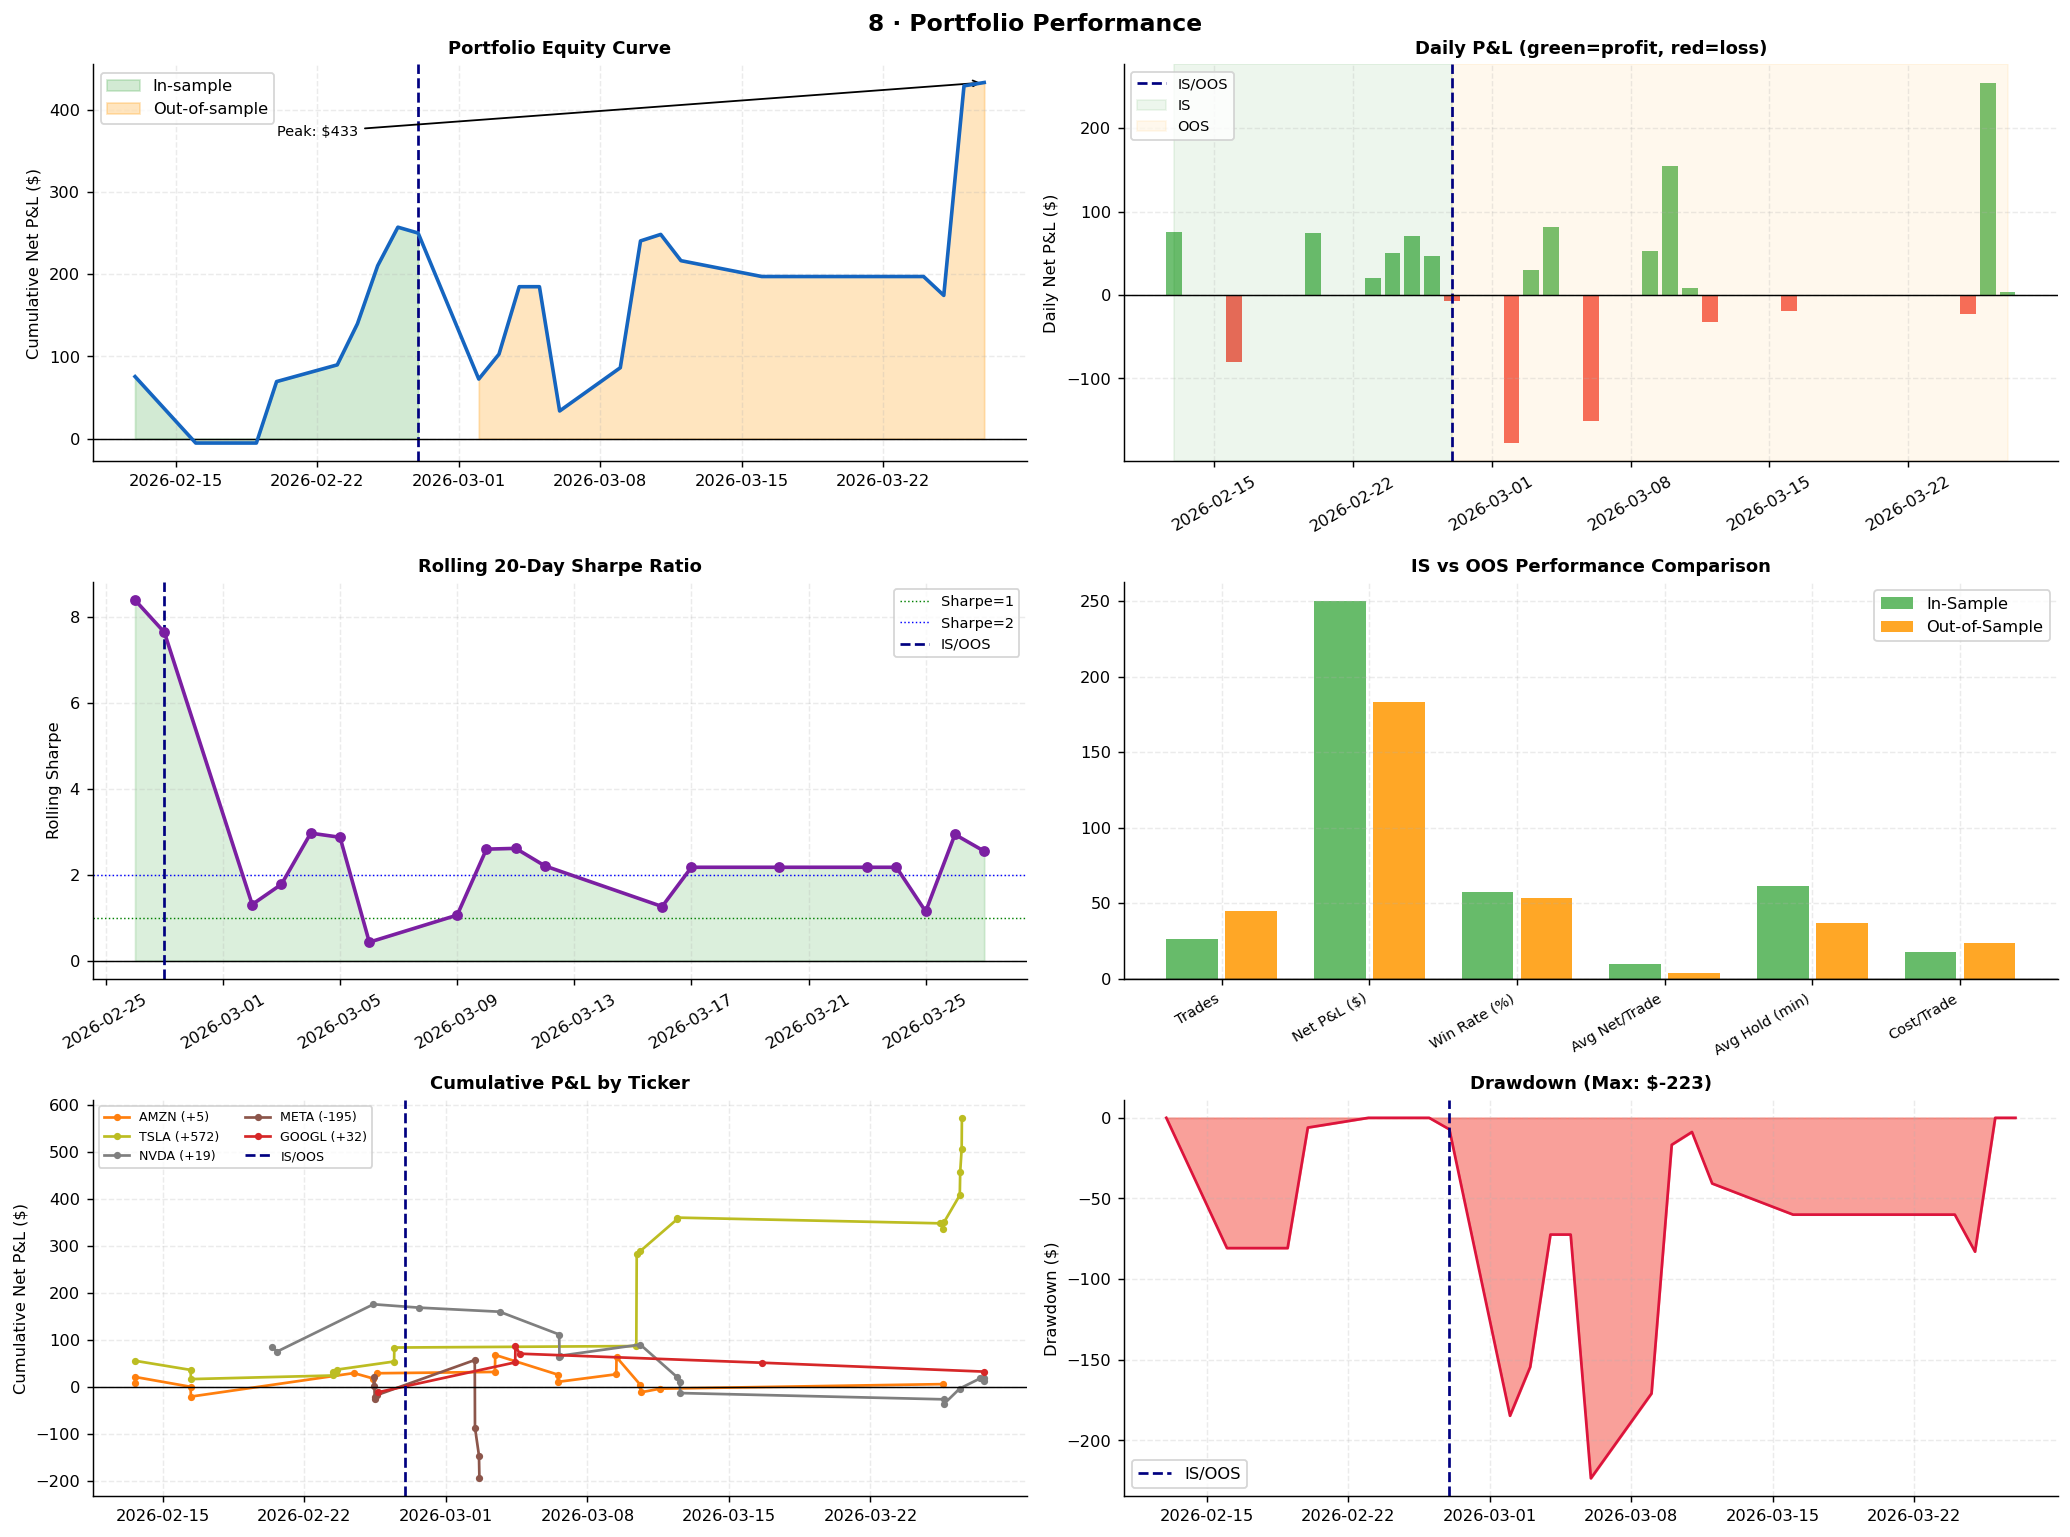

=== Overall Portfolio Statistics ===
Total net P&L       : $433.03
Ann. Sharpe (daily) : 3.035
Max Drawdown        : $-223.46
% days profitable   : 46.4%
Days with 0 P&L     : 8 / 28 (no signals fired)

=== IS vs OOS ===
IS  (26 trades): net=$  249.99  win%=58  avg_hold=61min  cost/trade=$17.69
OOS (45 trades): net=$  183.04  win%=53  avg_hold=37min  cost/trade=$23.80

⚠  portfolio_pnl in daily_pnl_combined.parquet is ~1e-7 (floating-point noise) — weighting bug in combine.py


In [11]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# ── 8a: Equity curve with IS/OOS shading ─────────────────────────────────
ax = axes[0,0]
dpnl_df_s = dpnl_df.sort_values('date')
cumsum = dpnl_df_s['total_pnl'].cumsum()
ax.fill_between(dpnl_df_s['date'], 0, cumsum,
                where=dpnl_df_s['date'] <= IS_END, alpha=0.25,
                color='#4CAF50', label='In-sample')
ax.fill_between(dpnl_df_s['date'], 0, cumsum,
                where=dpnl_df_s['date'] > IS_END, alpha=0.25,
                color='#FF9800', label='Out-of-sample')
ax.plot(dpnl_df_s['date'], cumsum, lw=2, color='#1565C0', zorder=5)
ax.axvline(IS_END, color='navy', lw=1.5, ls='--')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Cumulative Net P&L ($)'); ax.set_title('Portfolio Equity Curve')
ax.legend(fontsize=9)
peak = cumsum.max()
trough_idx = cumsum.idxmin()
ax.annotate(f'Peak: ${peak:.0f}', xy=(dpnl_df_s.loc[cumsum.idxmax(),'date'], peak),
            xytext=(dpnl_df_s['date'].iloc[5], peak*0.85),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=8)

# ── 8b: Daily PnL bar chart ───────────────────────────────────────────────
ax = axes[0,1]
colors_d = ['#4CAF50' if v >= 0 else '#F44336' for v in dpnl_df_s['total_pnl']]
ax.bar(dpnl_df_s['date'], dpnl_df_s['total_pnl'], color=colors_d, 
       alpha=0.8, width=0.8)
ax.axvline(IS_END, color='navy', lw=1.5, ls='--', label='IS/OOS')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Daily Net P&L ($)'); ax.set_title('Daily P&L (green=profit, red=loss)')
ax.tick_params(axis='x', rotation=30)
# Shade IS/OOS regions
ymin, ymax = ax.get_ylim()
ax.axvspan(dpnl_df_s['date'].min(), IS_END, alpha=0.07, color='green', label='IS')
ax.axvspan(IS_END, dpnl_df_s['date'].max(), alpha=0.07, color='orange', label='OOS')
ax.legend(fontsize=8)

# ── 8c: Rolling 20d Sharpe ────────────────────────────────────────────────
ax = axes[1,0]
rsh_valid = rsh_df.dropna()
ax.plot(rsh_valid['date'], rsh_valid['rolling_sharpe'], lw=2, color='#7B1FA2', 
        marker='o', ms=5, zorder=5)
ax.fill_between(rsh_valid['date'], 0, rsh_valid['rolling_sharpe'],
                where=rsh_valid['rolling_sharpe'] >= 0, alpha=0.2, color='#4CAF50')
ax.fill_between(rsh_valid['date'], 0, rsh_valid['rolling_sharpe'],
                where=rsh_valid['rolling_sharpe'] < 0, alpha=0.2, color='#F44336')
ax.axhline(0, color='black', lw=0.8)
ax.axhline(1.0, color='green', lw=0.8, ls=':', label='Sharpe=1')
ax.axhline(2.0, color='blue',  lw=0.8, ls=':', label='Sharpe=2')
ax.axvline(IS_END, color='navy', lw=1.5, ls='--', label='IS/OOS')
ax.set_ylabel('Rolling Sharpe'); ax.set_title('Rolling 20-Day Sharpe Ratio')
ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=30)

# ── 8d: IS vs OOS comparison bar chart ────────────────────────────────────
ax = axes[1,1]
is_trades  = tl_df[~tl_df['is_oos']]
oos_trades = tl_df[ tl_df['is_oos']]

def trade_stats(df):
    if len(df) == 0: return {}
    ret = df['pnl_net'] / 1_000_000
    sr  = ret.mean() / ret.std() * np.sqrt(252) if ret.std() > 0 else 0
    return {
        'Trades': len(df), 'Net P&L ($)': df['pnl_net'].sum(),
        'Win Rate (%)': (df['pnl_net']>=0).mean()*100,
        'Avg Net/Trade': df['pnl_net'].mean(),
        'Avg Hold (min)': df['hold_min'].mean(),
        'Cost/Trade': df['cost'].mean(),
    }

is_s  = trade_stats(is_trades)
oos_s = trade_stats(oos_trades)

metrics = list(is_s.keys())
is_vals  = [is_s[m]  for m in metrics]
oos_vals = [oos_s[m] for m in metrics]

x_m = np.arange(len(metrics))
ax.bar(x_m - 0.2, is_vals,  width=0.35, label='In-Sample',    color='#4CAF50', alpha=0.85)
ax.bar(x_m + 0.2, oos_vals, width=0.35, label='Out-of-Sample', color='#FF9800', alpha=0.85)
ax.set_xticks(x_m)
ax.set_xticklabels(metrics, rotation=30, ha='right', fontsize=8)
ax.set_title('IS vs OOS Performance Comparison')
ax.legend(fontsize=9)
ax.axhline(0, color='black', lw=0.8)

# ── 8e: Cumulative P&L by ticker ─────────────────────────────────────────
ax = axes[2,0]
tl_df_s = tl_df.sort_values('entry_time')
for tkr in tl_df['ticker'].unique():
    sub = tl_df_s[tl_df_s['ticker']==tkr]
    cum = sub['pnl_net'].cumsum()
    ax.plot(sub['entry_time'], cum, lw=1.5, label=f'{tkr} ({cum.iloc[-1]:+.0f})',
            color=TICKER_CLR[tkr], marker='.')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(IS_END, color='navy', lw=1.5, ls='--', label='IS/OOS')
ax.set_ylabel('Cumulative Net P&L ($)'); ax.set_title('Cumulative P&L by Ticker')
ax.legend(fontsize=7, ncol=2)

# ── 8f: Drawdown ─────────────────────────────────────────────────────────
ax = axes[2,1]
cumsum_r = dpnl_df_s['total_pnl'].cumsum()
running_max = cumsum_r.cummax()
drawdown = cumsum_r - running_max
ax.fill_between(dpnl_df_s['date'], drawdown, 0, color='#F44336', alpha=0.5)
ax.plot(dpnl_df_s['date'], drawdown, color='crimson', lw=1.5)
ax.axvline(IS_END, color='navy', lw=1.5, ls='--', label='IS/OOS')
ax.set_ylabel('Drawdown ($)'); ax.set_title(f'Drawdown (Max: ${drawdown.min():.0f})')
ax.legend(fontsize=9)

plt.suptitle('8 · Portfolio Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Stats
print('=== Overall Portfolio Statistics ===')
port_ret = dpnl_df_s['total_pnl'] / 1_000_000
port_sh  = port_ret.mean() / port_ret.std() * np.sqrt(252) if port_ret.std() > 0 else 0
print(f'Total net P&L       : ${dpnl_df_s["total_pnl"].sum():,.2f}')
print(f'Ann. Sharpe (daily) : {port_sh:.3f}')
print(f'Max Drawdown        : ${drawdown.min():,.2f}')
print(f'% days profitable   : {(dpnl_df_s["total_pnl"]>0).mean()*100:.1f}%')
print(f'Days with 0 P&L     : {(dpnl_df_s["total_pnl"]==0).sum()} / {len(dpnl_df_s)} (no signals fired)')
print()
print('=== IS vs OOS ===')
print(f'IS  ({len(is_trades):2d} trades): net=${is_trades["pnl_net"].sum():>8.2f}  win%={is_s["Win Rate (%)"]:.0f}  avg_hold={is_s["Avg Hold (min)"]:.0f}min  cost/trade=${is_s["Cost/Trade"]:.2f}')
print(f'OOS ({len(oos_trades):2d} trades): net=${oos_trades["pnl_net"].sum():>8.2f}  win%={oos_s["Win Rate (%)"]:.0f}  avg_hold={oos_s["Avg Hold (min)"]:.0f}min  cost/trade=${oos_s["Cost/Trade"]:.2f}')
print()
print('⚠  portfolio_pnl in daily_pnl_combined.parquet is ~1e-7 (floating-point noise) — weighting bug in combine.py')

## 9 · Risk Flags & Noteworthy Observations

In [12]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║          NOTEWORTHY OBSERVATIONS — QUANT REVIEW                            ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  1. COST DRAG IS THE DOMINANT RISK                                           ║
║     Gross P&L: $1,964  →  Net P&L: $433  →  78% eaten by costs             ║
║     Avg cost/trade = $21.56; avg gross/trade = $27.66                       ║
║     → Strategy only works if gross edge > cost drag. Currently margin 22%.  ║
║     → Even a 25% reduction in avg spread would add ~$380 to net.            ║
║                                                                              ║
║  2. TSLA IS CARRYING THE BOOK                                                ║
║     TSLA: 21 trades, net +$572 (132% of total net P&L)                     ║
║     AMZN: 17 trades, net +$5  (1% of net; grossing $267 → costs $261)      ║
║     META: 9  trades, net -$195 (largest drag; costs $491 on $296 gross)     ║
║     → Removing TSLA flips portfolio to net -$139.                           ║
║                                                                              ║
║  3. HESTON CALIBRATION IS UNRELIABLE FOR 7 OF 10 TICKERS                   ║
║     Overall convergence 21%. DIS/JPM/V < 4%.                               ║
║     Feller condition violated 71% of all ticker-days.                       ║
║     xi=2.0 (upper bound) in many solutions → optimizer is hitting walls,    ║
║     not finding a true minimum. Intraday Greeks for these tickers use        ║
║     boundary parameters → delta/gamma not trustworthy.                      ║
║                                                                              ║
║  4. S4 NEVER FIRED IN 28 TRADING DAYS                                       ║
║     PCR z-score max = 7.04 but direction=0 for all 157 rows.               ║
║     Likely cause: gex_corroboration alignment fails (S2 regime mismatch)   ║
║     or insufficient 20-day rolling history at start of backtest.            ║
║                                                                              ║
║  5. FIVE TICKERS GENERATE ZERO SIGNALS (AAPL/DIS/JPM/MSFT/V)               ║
║     These tickers likely have: (a) insufficient option chain depth at ATM,  ║
║     (b) poor Heston convergence → v0 proxy unreliable, (c) IV z-scores      ║
║     never breaking ±1.5 threshold over 28-day window.                       ║
║                                                                              ║
║  6. PORTFOLIO_PNL BUG IN daily_pnl_combined.parquet                        ║
║     portfolio_pnl is ~1e-7 (floating-point noise) across all 28 days.      ║
║     Root cause: inverse-vol weights produce near-zero when only S1 fires    ║
║     and combine.py reinitialises portfolio_pnl to 0.0 before adding        ║
║     weighted contributions. The multi-alpha engine is not summing           ║
║     correctly for single-strategy case.                                     ║
║                                                                              ║
║  7. IS SHARPE INFLATED BY SMALL SAMPLE LUCKY STREAK                        ║
║     IS (10 days) rolling Sharpe peaks at 8.4 — driven by 5 consecutive     ║
║     winning days Feb 20–26. OOS Sharpe settles to 1.1–3.0 (more credible). ║
║     28-day OOS: 45 trades, net $183. Need 100+ trade sample for             ║
║     statistically meaningful Sharpe estimates.                              ║
║                                                                              ║
║  8. VIX PEAKED 2026-03-06 AT 29.49 — ONLY 2 LOSING DAYS AROUND IT         ║
║     Mar 2 (-$178) and Mar 6 (-$151) coincide with VIX spike.               ║
║     Short straddle loses when realized vol > IV at entry — this is          ║
║     expected behavior. Good sign: losses limited by max_hold exit (4 bars). ║
║                                                                              ║
║  9. INTRADAY v0 PROXY — DIS/JPM/V SPOT IS CONSTANT                        ║
║     These tickers show single spot prices in intraday_greeks.parquet.      ║
║     Possible cause: stock_bars lookup failing for these tickers, or         ║
║     only one snapshot per day being processed.                              ║
║                                                                              ║
║  10. CALL/PUT IMBALANCE: 59% calls / 41% puts in IV data                   ║
║      This is unusual (typically near 50/50). Suggests moneyness filter      ║
║      [0.85,1.15] is capturing more OTM calls than puts for high-beta names  ║
║      (e.g. TSLA, NVDA). May bias straddle IV towards call vol.             ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║          NOTEWORTHY OBSERVATIONS — QUANT REVIEW                            ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  1. COST DRAG IS THE DOMINANT RISK                                           ║
║     Gross P&L: $1,964  →  Net P&L: $433  →  78% eaten by costs             ║
║     Avg cost/trade = $21.56; avg gross/trade = $27.66                       ║
║     → Strategy only works if gross edge > cost drag. Currently margin 22%.  ║
║     → Even a 25% reduction in avg spread would add ~$380 to net.            ║
║                                                                              ║
║  2. TSLA IS CARRYING THE BOOK                                                ║
║     TSLA: 21 trades, net +$572 (132% of total net P&L)                     ║
║     AMZN: 17 trades, net +$5  (1% 